# Detailed plot tool

## Initial grouping code

In [57]:
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_FOLDER = Path(r"C:\Users\mpciv\Downloads\LVM-20260319T152800Z-3-001\LVM")

LAYER1_COLS_1BASED = (1, 30)
LAYER2_COLS_1BASED = (33, 62)   # 30 columns

def read_lvm_file(file_path: Path) -> pd.DataFrame:
    return pd.read_csv(file_path, sep=r"\s+", header=None, engine="python")

def extract_1based_inclusive(df: pd.DataFrame, start: int, end: int) -> np.ndarray:
    return df.iloc[:, start - 1:end].to_numpy()

def parse_filename(file_path: Path):
    parts = file_path.stem.split("_")

    # Examples:
    # Cyl100_Re100k_Clean
    # Cyl100_Re100k_Trip_0.15_A57

    meta = {
        "cylinder": parts[0],
        "re": parts[1],          # e.g. Re100k
        "case": None,            # Clean or Trip
        "trip_mm": None,         # e.g. 0.15 or 0.94
        "angle": None            # e.g. 57
    }

    if len(parts) == 3 and parts[2] == "Clean":
        meta["case"] = "Clean"

    elif len(parts) == 5 and parts[2] == "Trip":
        meta["case"] = "Trip"
        meta["trip_mm"] = parts[3]                  # "0.15" or "0.94"
        meta["angle"] = parts[4].replace("A", "")  # "57", "33", etc.

    else:
        raise ValueError(f"Unexpected filename format: {file_path.name}")

    return meta

# Grouped storage
# Example key for trip cases: ("Trip", "0.94", "57")
# Example key for clean cases: ("Clean",)
grouped_results = defaultdict(list)

for file in DATA_FOLDER.glob("*.lvm"):
    FILE_PATH = file
    meta = parse_filename(FILE_PATH)

    df = read_lvm_file(FILE_PATH)

    # -----------------------------
    # Extract the two pressure layers
    # -----------------------------
    layer1 = extract_1based_inclusive(df, *LAYER1_COLS_1BASED)
    layer2 = extract_1based_inclusive(df, *LAYER2_COLS_1BASED)

    p1_mean = layer1.mean(axis=0)
    p2_mean = layer2.mean(axis=0)

    theta1 = np.arange(0.0, 360.0, 12.0)
    theta2 = theta1 + 6.0

    theta_collapsed = np.arange(0.0, 360.0, 6.0)

    p_collapsed = np.empty(theta_collapsed.size)
    p_collapsed[0::2] = p1_mean
    p_collapsed[1::2] = p2_mean

    # -----------------------------
    # Convert pressure to Cp
    # -----------------------------
    q_inf_mean = df.iloc[:, 63].mean()   # 64th column = pitot channel

    cp1_mean = p1_mean / q_inf_mean
    cp2_mean = p2_mean / q_inf_mean

    cp_collapsed = np.empty(theta_collapsed.size)

    # keep your working ordering
    cp_collapsed[0::2] = cp2_mean
    cp_collapsed[1::2] = cp1_mean

    # repeat the first point at the end to close the loop
    theta_collapsed_closed = np.r_[theta_collapsed, 360.0]
    cp_collapsed_closed = np.r_[cp_collapsed, cp_collapsed[0]]

    # -----------------------------
    # Group the results
    # -----------------------------
    if meta["case"] == "Clean":
        group_key = ("Clean",)
    else:
        group_key = ("Trip", meta["trip_mm"], meta["angle"])

    grouped_results[group_key].append({
        "file_name": FILE_PATH.name,
        "re": meta["re"],
        "theta": theta_collapsed_closed,
        "cp": cp_collapsed_closed
    })


## Specific angle and tripwire plotter, combined Reynolds number

### This code prints out the combined graph for a specific tripwire angle and thickness. All reynold numbers are combined into the same graph, to give an idea of changes due to reynolds number.

File: Cyl100_Re50k_Trip_0.15_A63.lvm
Mean pitot pressure q_inf = 33.6712
C_D = 1.2217
C_L = -0.0102


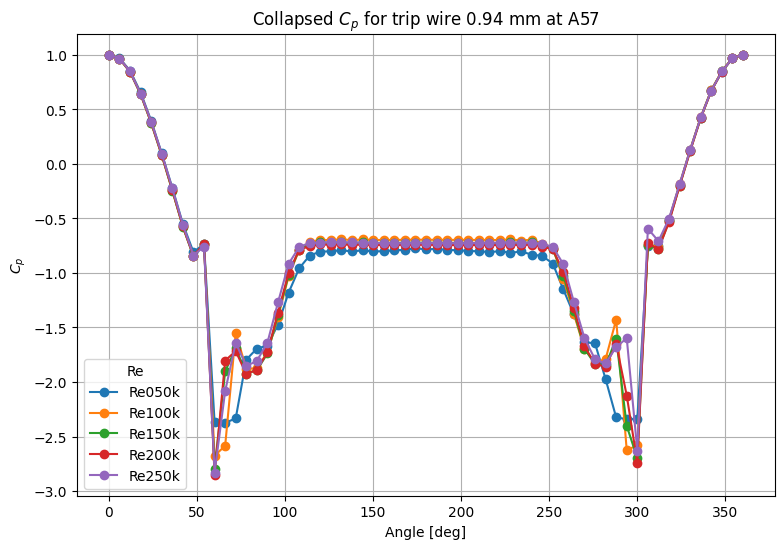

In [58]:
# Example 1:
# Plot all runs for 0.94 mm wire at angle 57

print(f"File: {FILE_PATH.name}")
print(f"Mean pitot pressure q_inf = {q_inf_mean:.4f}")
print(f"C_D = {C_D:.4f}")
print(f"C_L = {C_L:.4f}")


target_key = ("Trip", "0.94", "57")

if target_key in grouped_results:
    plt.figure(figsize=(9, 6))

    # sort by Reynolds number numerically
    def re_value(run_dict):
        return int(run_dict["re"].replace("Re", "").replace("k", ""))

    for run_data in sorted(grouped_results[target_key], key=re_value):
        plt.plot(
            run_data["theta"],
            run_data["cp"],
            "o-",
            label=run_data["re"]
        )


    plt.xlabel("Angle [deg]")
    plt.ylabel("$C_p$")
    plt.title("Collapsed $C_p$ for trip wire 0.94 mm at A57")
    plt.grid(True)
    plt.legend(title="Re")
    plt.show()

else:
    print(f"No files found for group {target_key}")

## Clean cylinder run

### Clean cylinder has its own since the name sorting of the code doesnt work the same for the clean files. In this code all reynolds numbers are combined into the same graph.

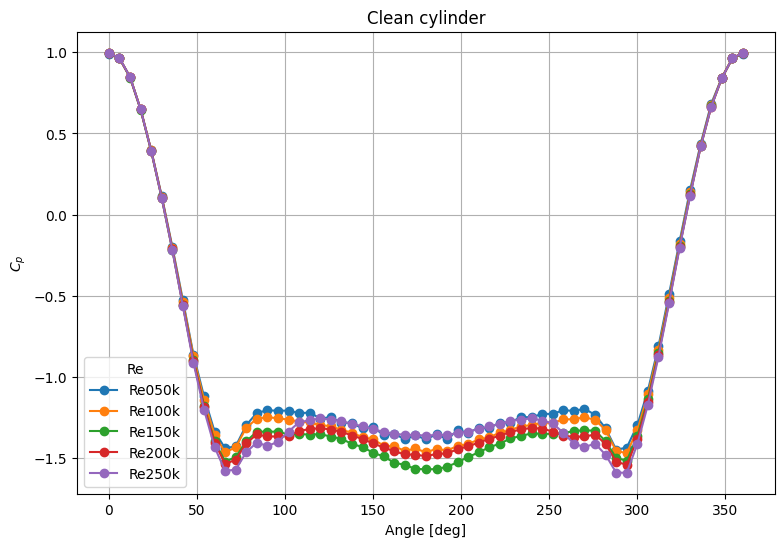

In [59]:
if ("Clean",) in grouped_results:
    plt.figure(figsize=(9, 6))

    def re_value(run_dict):
        return int(run_dict["re"].replace("Re", "").replace("k", ""))

    for run_data in sorted(grouped_results[("Clean",)], key=re_value):
        plt.plot(
            run_data["theta"],
            run_data["cp"],
            "o-",
            label=run_data["re"]
        )

    plt.xlabel("Angle [deg]")
    plt.ylabel("$C_p$")
    plt.title("Clean cylinder")
    plt.grid(True)
    plt.legend(title="Re")





## Individual reynolds numbers for a specific thickness and angle

### Using the target key, this code displays all vallues collected at a spefific reynolds number, again for a pre set wire thickness and angle. They are printed in order after starting from Re = 50.000

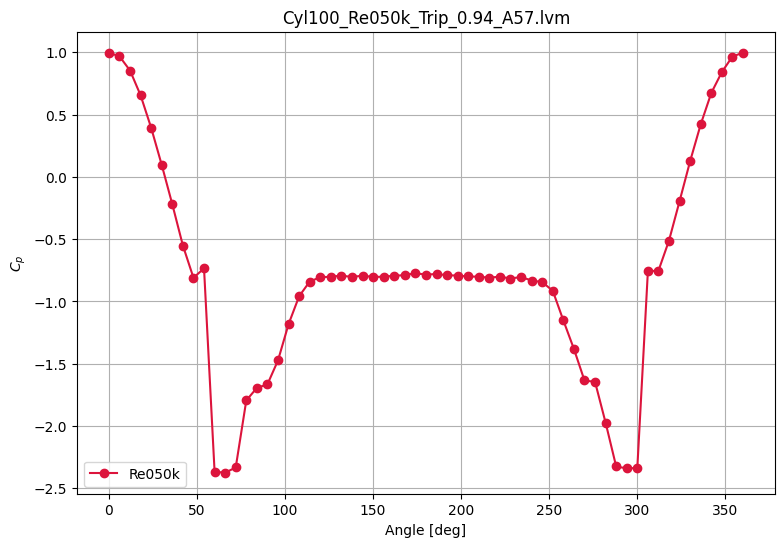

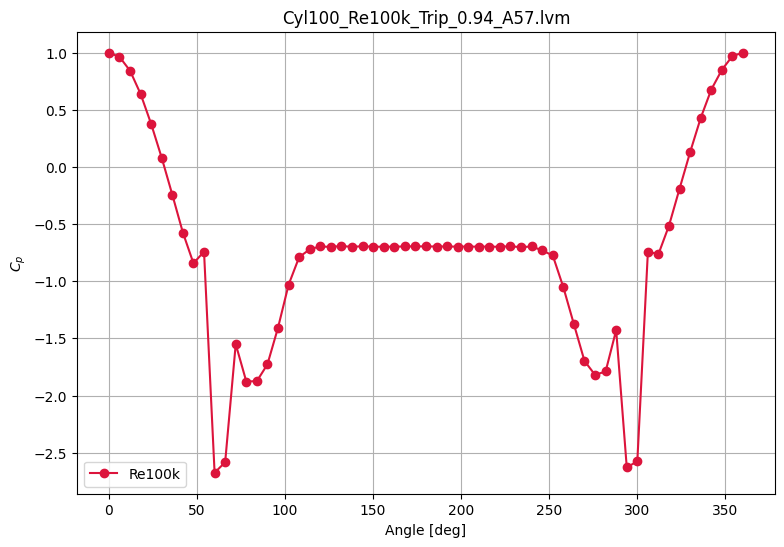

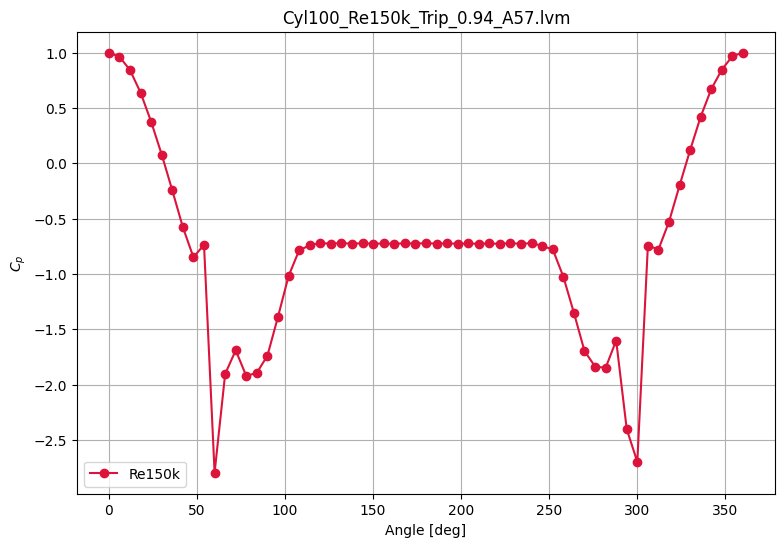

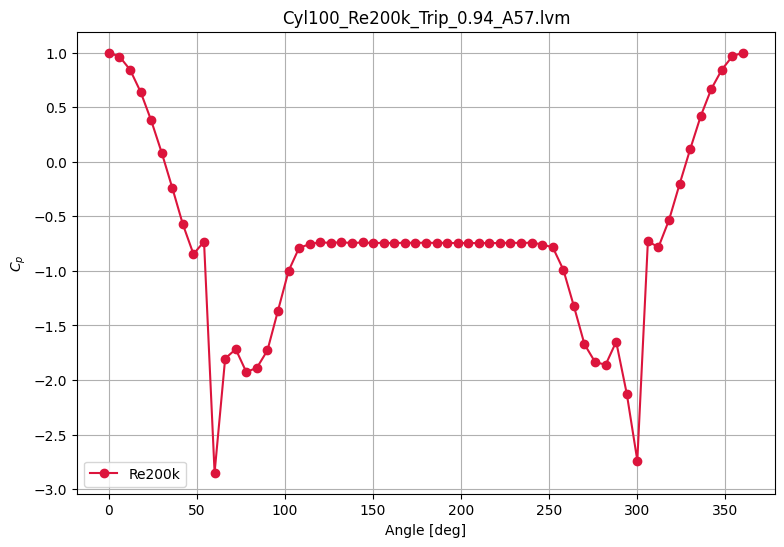

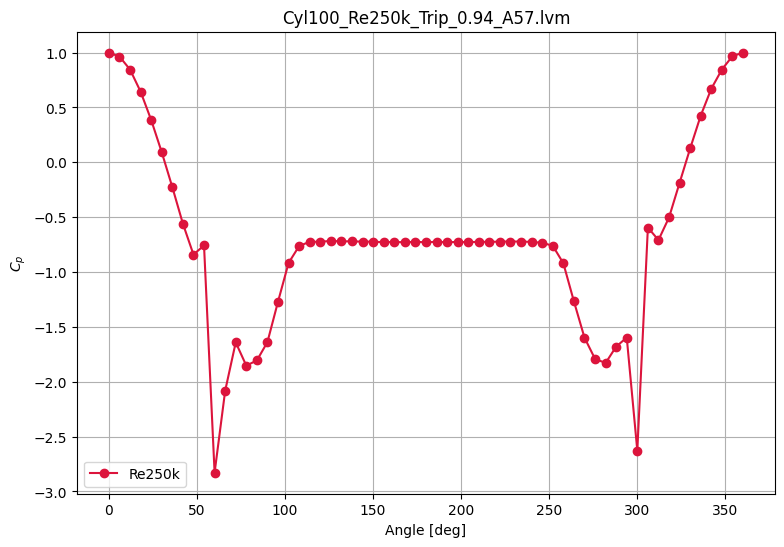

In [60]:
target_key = ("Trip", "0.94", "57")

if target_key in grouped_results:

    def re_value(run_dict):
        return int(run_dict["re"].replace("Re", "").replace("k", ""))

    for run_data in sorted(grouped_results[target_key], key=re_value):
        plt.figure(figsize=(9, 6))

        plt.plot(
            run_data["theta"],
            run_data["cp"],
            "o-",
            label=run_data["re"],
            color = "crimson"
        )

        plt.xlabel("Angle [deg]")
        plt.ylabel("$C_p$")
        plt.title(f'{run_data["file_name"]}')
        plt.grid(True)
        plt.legend()


    plt.show()

else:
    print(f"No files found for group {target_key}")

## All runs, combined, without Clean

### Each graph represents a run, that being where tripwire thickness and angle stay the same, and the reynolds number changes. These are all plotted in one graph, to illustrate the differences between each reynolds number

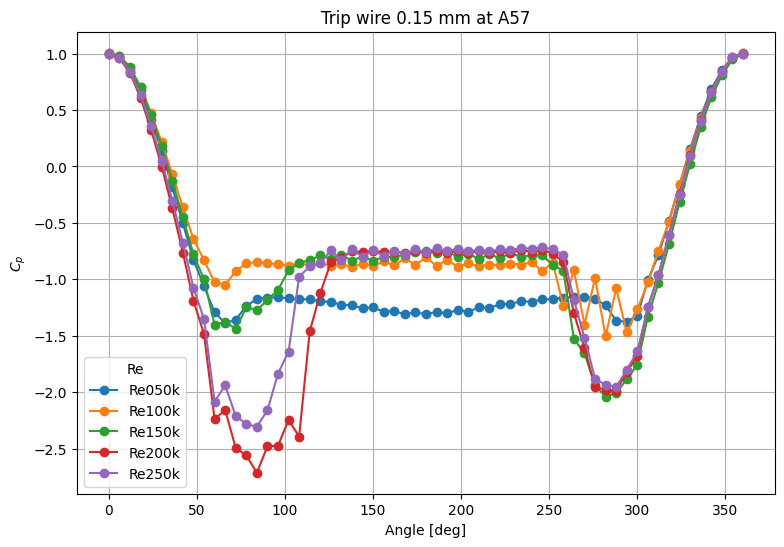

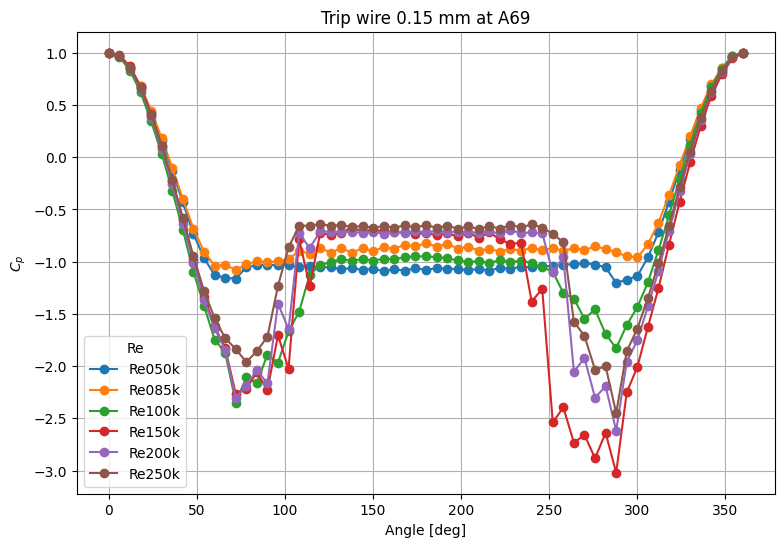

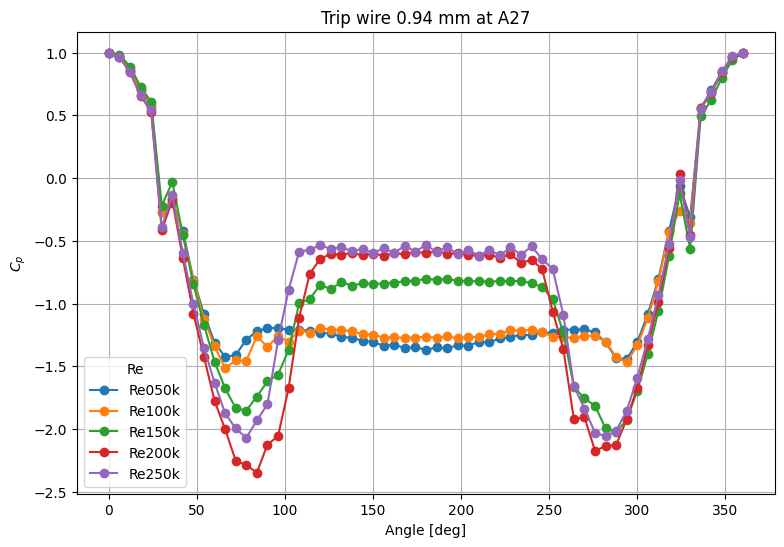

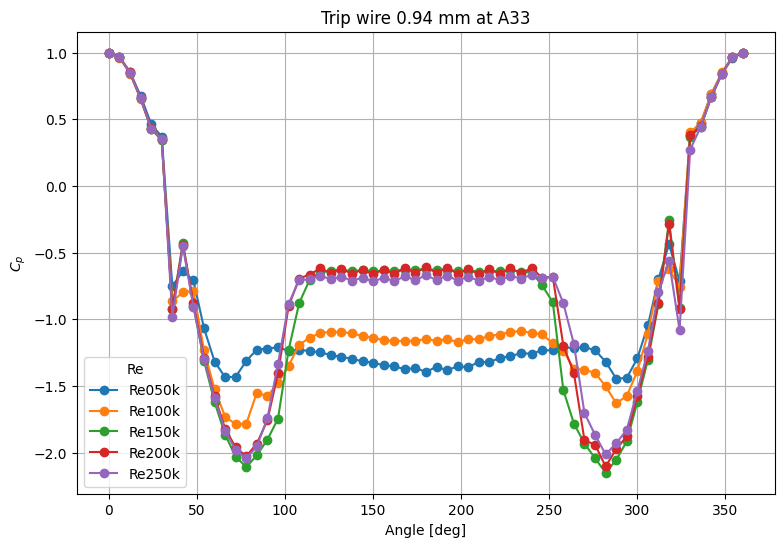

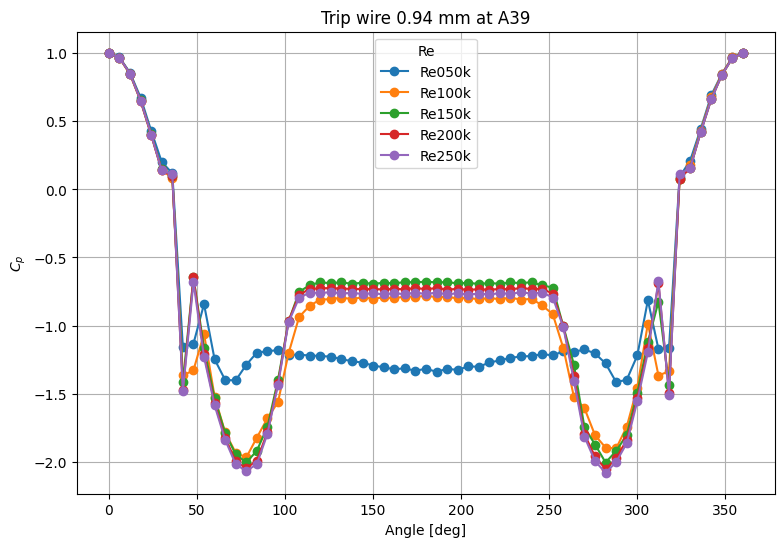

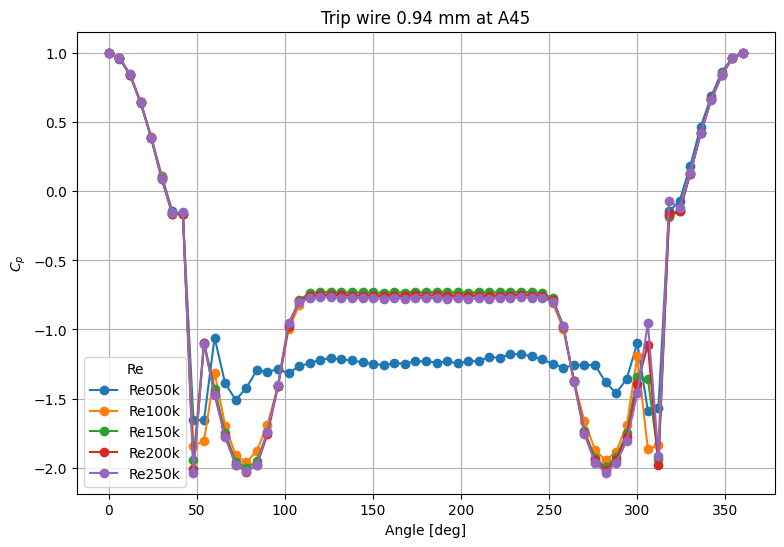

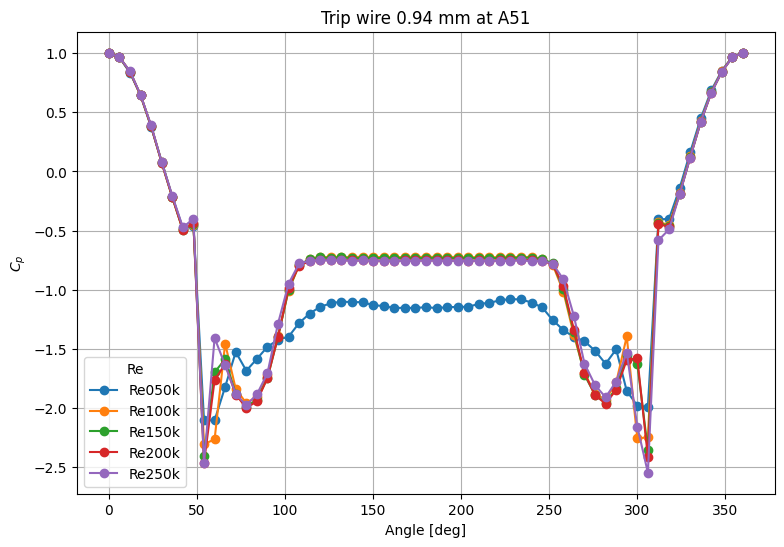

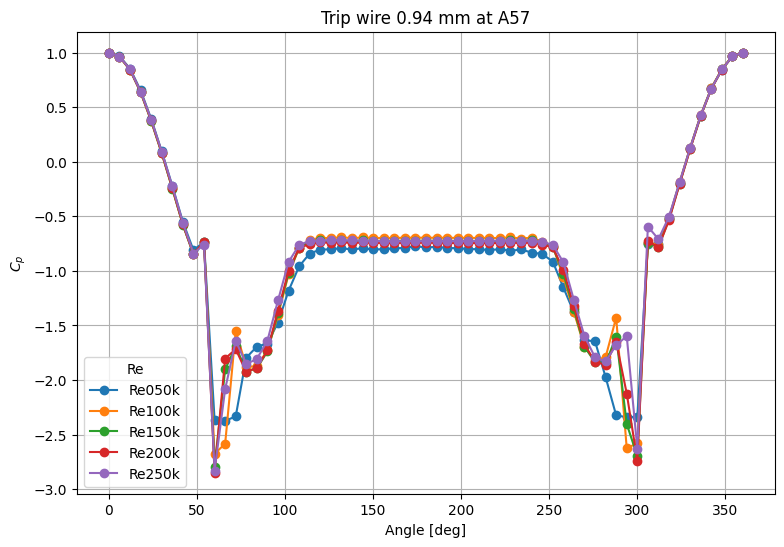

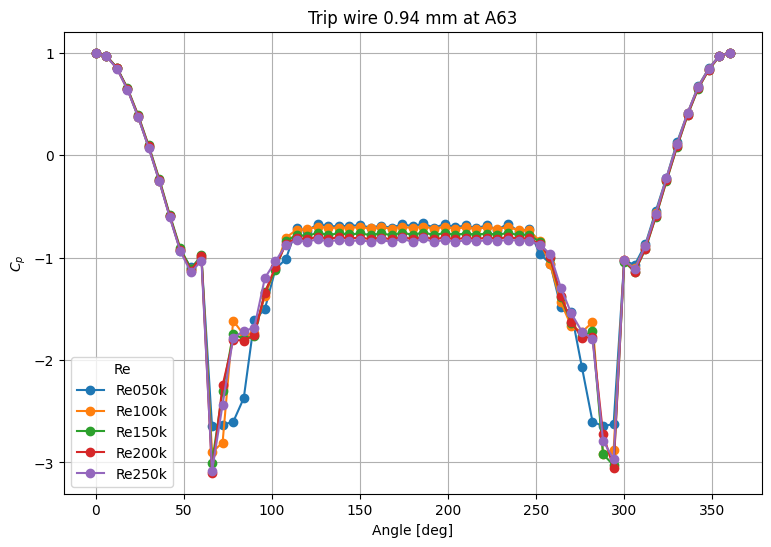

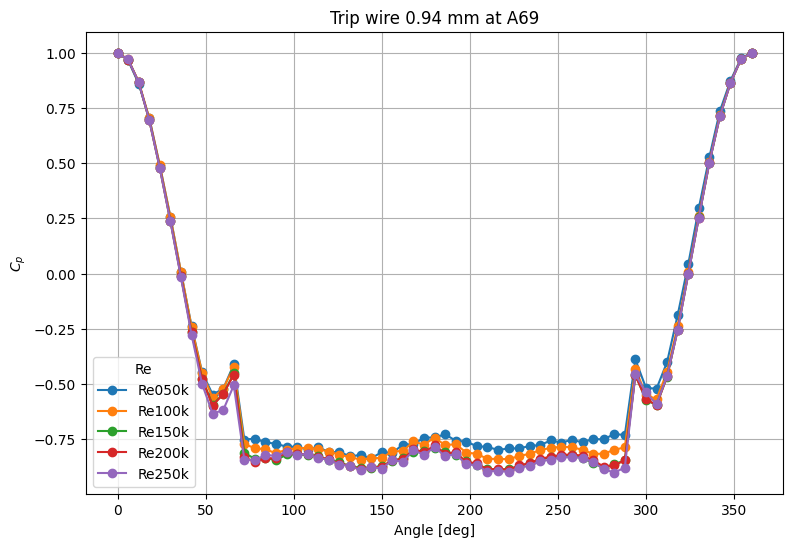

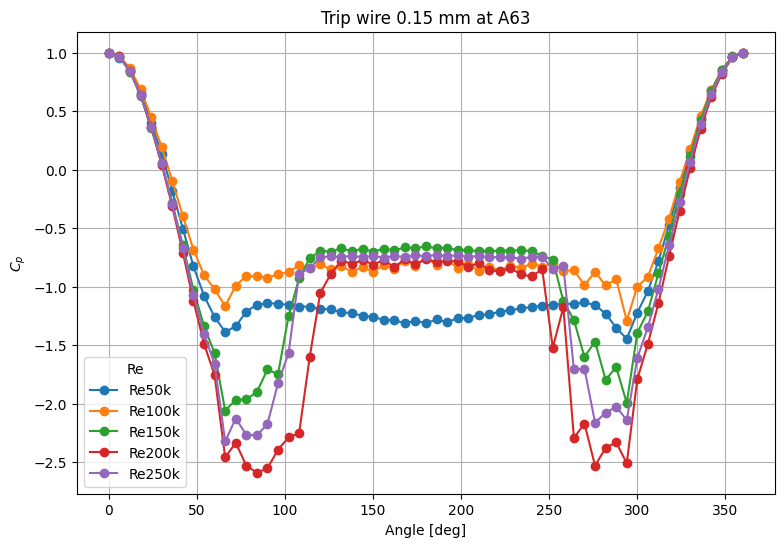

In [61]:
for group_key, runs in grouped_results.items():
    if group_key[0] != "Trip":
        continue

    case, trip_mm, angle = group_key

    plt.figure(figsize=(9, 6))

    def re_value(run_dict):
        return int(run_dict["re"].replace("Re", "").replace("k", ""))

    for run_data in sorted(runs, key=re_value):
        plt.plot(
            run_data["theta"],
            run_data["cp"],
            "o-",
            label=run_data["re"]
        )

    plt.xlabel("Angle [deg]")
    plt.ylabel("$C_p$")
    plt.title(f"Trip wire {trip_mm} mm at A{angle}")
    plt.grid(True)
    plt.legend(title="Re")


## C_D and vs Reynolds Number 

### Code for plotting C_D vs Reynolds number - Including table with sorted values

In [62]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_FOLDER = Path(r"C:\Users\mpciv\Downloads\LVM-20260319T152800Z-3-001\LVM")

LAYER1_COLS_1BASED = (1, 30)
LAYER2_COLS_1BASED = (33, 62)

def read_lvm_file(file_path: Path) -> pd.DataFrame:
    return pd.read_csv(file_path, sep=r"\s+", header=None, engine="python")

def extract_1based_inclusive(df: pd.DataFrame, start: int, end: int) -> np.ndarray:
    return df.iloc[:, start - 1:end].to_numpy()

def parse_filename(file_path: Path):
    parts = file_path.stem.split("_")

    meta = {
        "file": file_path.name,
        "re": int(parts[1].replace("Re", "").replace("k", "")) * 1000,
        "case": None,
        "trip_mm": None,
        "angle": None
    }

    if len(parts) == 3 and parts[2] == "Clean":
        meta["case"] = "Clean"

    elif len(parts) == 5 and parts[2] == "Trip":
        meta["case"] = "Trip"
        meta["trip_mm"] = float(parts[3])
        meta["angle"] = int(parts[4].replace("A", ""))

    else:
        raise ValueError(f"Unexpected filename format: {file_path.name}")

    return meta

results = []

for FILE_PATH in sorted(DATA_FOLDER.glob("*.lvm")):
    meta = parse_filename(FILE_PATH)
    df = read_lvm_file(FILE_PATH)

    layer1 = extract_1based_inclusive(df, *LAYER1_COLS_1BASED)
    layer2 = extract_1based_inclusive(df, *LAYER2_COLS_1BASED)

    p1_mean = layer1.mean(axis=0)
    p2_mean = layer2.mean(axis=0)

    theta_collapsed = np.arange(0.0, 360.0, 6.0)

    q_inf_mean = df.iloc[:, 63].mean()   # pitot channel

    cp1_mean = p1_mean / q_inf_mean
    cp2_mean = p2_mean / q_inf_mean

    cp_collapsed = np.empty(theta_collapsed.size)
    cp_collapsed[0::2] = cp2_mean
    cp_collapsed[1::2] = cp1_mean

    theta_collapsed_closed = np.r_[theta_collapsed, 360.0]
    cp_collapsed_closed = np.r_[cp_collapsed, cp_collapsed[0]]

    theta_rad_closed = np.deg2rad(theta_collapsed_closed)

    # sign chosen to match your current angle convention
    C_D = 0.5 * np.trapz(cp_collapsed_closed * np.cos(theta_rad_closed), theta_rad_closed)
    C_L = 0.5 * np.trapz(cp_collapsed_closed * np.sin(theta_rad_closed), theta_rad_closed)

    results.append({
        "file": meta["file"],
        "Re": meta["re"],
        "case": meta["case"],
        "trip_mm": meta["trip_mm"],
        "angle": meta["angle"],
        "C_D": C_D,
        "C_L": C_L
    })

results_df = pd.DataFrame(results)

def config_label(row):
    if row["case"] == "Clean":
        return "Clean"
    return f'A{int(row["angle"])}'

results_df["config"] = results_df.apply(config_label, axis=1)

print(results_df.sort_values(["case", "trip_mm", "angle", "Re"]).to_string(index=False))



                           file     Re  case  trip_mm  angle      C_D       C_L config
        Cyl100_Re050k_Clean.lvm  50000 Clean      NaN    NaN 1.269470 -0.008466  Clean
        Cyl100_Re100k_Clean.lvm 100000 Clean      NaN    NaN 1.326420 -0.004858  Clean
        Cyl100_Re150k_Clean.lvm 150000 Clean      NaN    NaN 1.390817 -0.010077  Clean
        Cyl100_Re200k_Clean.lvm 200000 Clean      NaN    NaN 1.329877 -0.005307  Clean
        Cyl100_Re250k_Clean.lvm 250000 Clean      NaN    NaN 1.233705 -0.001398  Clean
Cyl100_Re050k_Trip_0.15_A57.lvm  50000  Trip     0.15   57.0 1.228104 -0.008007    A57
Cyl100_Re100k_Trip_0.15_A57.lvm 100000  Trip     0.15   57.0 0.903883  0.153809    A57
Cyl100_Re150k_Trip_0.15_A57.lvm 150000  Trip     0.15   57.0 0.693825  0.232434    A57
Cyl100_Re200k_Trip_0.15_A57.lvm 200000  Trip     0.15   57.0 0.609682 -0.487066    A57
Cyl100_Re250k_Trip_0.15_A57.lvm 250000  Trip     0.15   57.0 0.585929 -0.240304    A57
 Cyl100_Re50k_Trip_0.15_A63.lvm  50000  Tri

### All C_D vs Reynolds, in a collective plot

                           file     Re  case  trip_mm  angle      C_D       C_L           config
        Cyl100_Re050k_Clean.lvm  50000 Clean      NaN    NaN 1.269470 -0.008466            Clean
        Cyl100_Re100k_Clean.lvm 100000 Clean      NaN    NaN 1.326420 -0.004858            Clean
        Cyl100_Re150k_Clean.lvm 150000 Clean      NaN    NaN 1.390817 -0.010077            Clean
        Cyl100_Re200k_Clean.lvm 200000 Clean      NaN    NaN 1.329877 -0.005307            Clean
        Cyl100_Re250k_Clean.lvm 250000 Clean      NaN    NaN 1.233705 -0.001398            Clean
Cyl100_Re050k_Trip_0.15_A57.lvm  50000  Trip     0.15   57.0 1.228104 -0.008007 Trip 0.15 mm A57
Cyl100_Re100k_Trip_0.15_A57.lvm 100000  Trip     0.15   57.0 0.903883  0.153809 Trip 0.15 mm A57
Cyl100_Re150k_Trip_0.15_A57.lvm 150000  Trip     0.15   57.0 0.693825  0.232434 Trip 0.15 mm A57
Cyl100_Re200k_Trip_0.15_A57.lvm 200000  Trip     0.15   57.0 0.609682 -0.487066 Trip 0.15 mm A57
Cyl100_Re250k_Trip_0.15_A57.lv

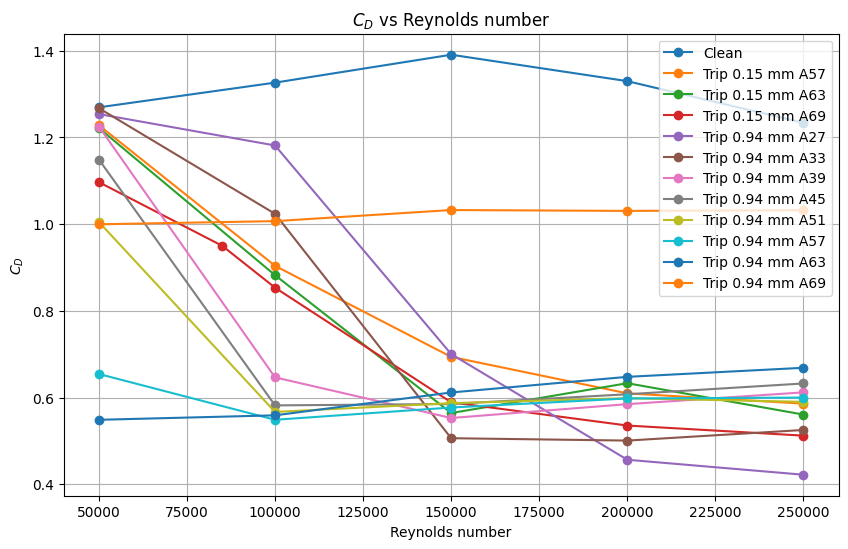

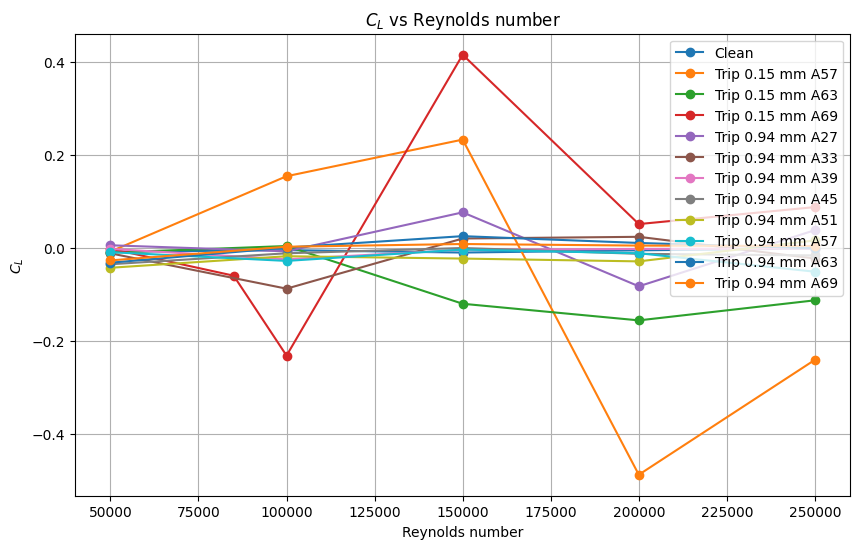

In [63]:
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_FOLDER = Path(r"C:\Users\mpciv\Downloads\LVM-20260319T152800Z-3-001\LVM")

LAYER1_COLS_1BASED = (1, 30)
LAYER2_COLS_1BASED = (33, 62)

def read_lvm_file(file_path: Path) -> pd.DataFrame:
    return pd.read_csv(file_path, sep=r"\s+", header=None, engine="python")

def extract_1based_inclusive(df: pd.DataFrame, start: int, end: int) -> np.ndarray:
    return df.iloc[:, start - 1:end].to_numpy()

def parse_filename(file_path: Path):
    parts = file_path.stem.split("_")

    meta = {
        "file": file_path.name,
        "re": int(parts[1].replace("Re", "").replace("k", "")) * 1000,
        "case": None,
        "trip_mm": None,
        "angle": None
    }

    if len(parts) == 3 and parts[2] == "Clean":
        meta["case"] = "Clean"

    elif len(parts) == 5 and parts[2] == "Trip":
        meta["case"] = "Trip"
        meta["trip_mm"] = float(parts[3])
        meta["angle"] = int(parts[4].replace("A", ""))

    else:
        raise ValueError(f"Unexpected filename format: {file_path.name}")

    return meta

results = []

for FILE_PATH in sorted(DATA_FOLDER.glob("*.lvm")):
    meta = parse_filename(FILE_PATH)
    df = read_lvm_file(FILE_PATH)

    layer1 = extract_1based_inclusive(df, *LAYER1_COLS_1BASED)
    layer2 = extract_1based_inclusive(df, *LAYER2_COLS_1BASED)

    p1_mean = layer1.mean(axis=0)
    p2_mean = layer2.mean(axis=0)

    theta_collapsed = np.arange(0.0, 360.0, 6.0)

    q_inf_mean = df.iloc[:, 63].mean()   # pitot channel

    cp1_mean = p1_mean / q_inf_mean
    cp2_mean = p2_mean / q_inf_mean

    cp_collapsed = np.empty(theta_collapsed.size)
    cp_collapsed[0::2] = cp2_mean
    cp_collapsed[1::2] = cp1_mean

    theta_collapsed_closed = np.r_[theta_collapsed, 360.0]
    cp_collapsed_closed = np.r_[cp_collapsed, cp_collapsed[0]]

    theta_rad_closed = np.deg2rad(theta_collapsed_closed)

    # positive sign to match your current angle convention
    C_D = 0.5 * np.trapz(cp_collapsed_closed * np.cos(theta_rad_closed), theta_rad_closed)
    C_L = 0.5 * np.trapz(cp_collapsed_closed * np.sin(theta_rad_closed), theta_rad_closed)

    results.append({
        "file": meta["file"],
        "Re": meta["re"],
        "case": meta["case"],
        "trip_mm": meta["trip_mm"],
        "angle": meta["angle"],
        "C_D": C_D,
        "C_L": C_L
    })

results_df = pd.DataFrame(results)

# -----------------------------
# Build configuration labels
# -----------------------------
def config_label(row):
    if row["case"] == "Clean":
        return "Clean"
    return f'Trip {row["trip_mm"]:.2f} mm A{int(row["angle"])}'

results_df["config"] = results_df.apply(config_label, axis=1)

print(results_df.sort_values(["config", "Re"]).to_string(index=False))

# -----------------------------
# Plot C_D vs Re with one line per configuration
# -----------------------------
plt.figure(figsize=(10, 6))

for config, group in results_df.groupby("config"):
    group = group.sort_values("Re")
    plt.plot(group["Re"], group["C_D"], "o-", label=config)

plt.xlabel("Reynolds number")
plt.ylabel("$C_D$")
plt.title("$C_D$ vs Reynolds number")
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Plot C_L vs Re with one line per configuration
# -----------------------------
plt.figure(figsize=(10, 6))

for config, group in results_df.groupby("config"):
    group = group.sort_values("Re")
    plt.plot(group["Re"], group["C_L"], "o-", label=config)

plt.xlabel("Reynolds number")
plt.ylabel("$C_L$")
plt.title("$C_L$ vs Reynolds number")
plt.grid(True)
plt.legend()
plt.show()

### Clean cylinder C_D vs Reynolds number

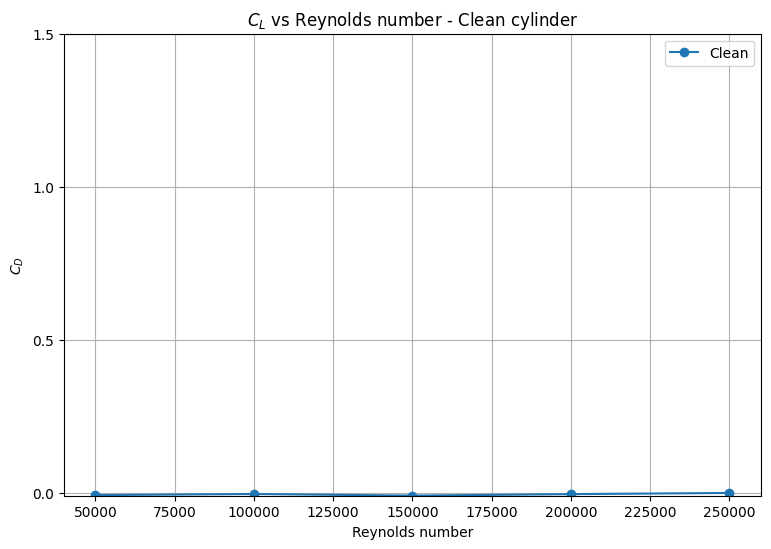

In [64]:

# -----------------------------
# Plot 1: Clean only
# -----------------------------
clean_df = results_df[results_df["case"] == "Clean"].sort_values("Re")

plt.figure(figsize=(9, 6))
plt.plot(clean_df["Re"], clean_df["C_L"], "o-", label="Clean")
plt.xlabel("Reynolds number")
# Source - https://stackoverflow.com/a/43287142
# Posted by Novel
# Retrieved 2026-03-25, License - CC BY-SA 3.0

plt.yticks([0,0.5,1,1.5])
plt.ylabel("$C_D$")
plt.title("$C_L$ vs Reynolds number - Clean cylinder")
plt.grid(True)
plt.legend()
plt.show()

### 0.15mm trip wire, C_D vs Reynolds number

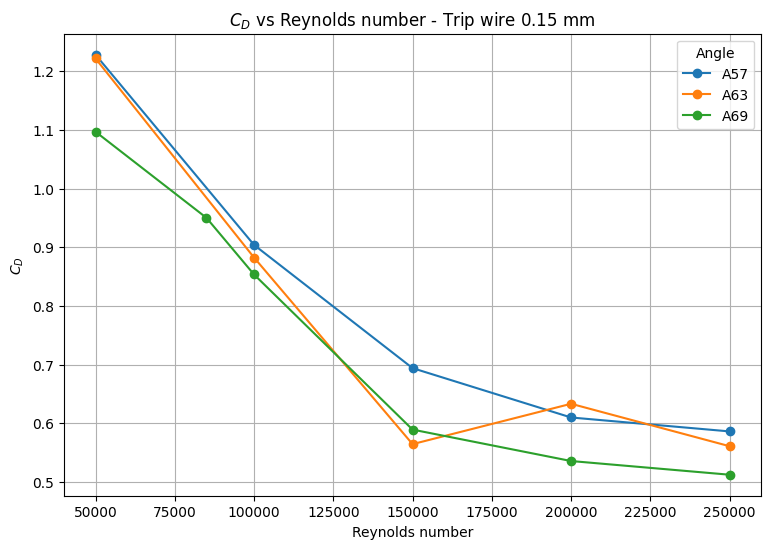

In [65]:
# -----------------------------
# Plot 2: 0.15 mm trip only
# one line per angle
# -----------------------------
trip015_df = results_df[
    (results_df["case"] == "Trip") & (results_df["trip_mm"] == 0.15)
]

plt.figure(figsize=(9, 6))
for angle, group in trip015_df.groupby("angle"):
    group = group.sort_values("Re")
    plt.plot(group["Re"], group["C_D"], "o-", label=f"A{int(angle)}")

plt.xlabel("Reynolds number")
plt.ylabel("$C_D$")
plt.title("$C_D$ vs Reynolds number - Trip wire 0.15 mm")
plt.grid(True)
plt.legend(title="Angle")
plt.show()

### 0.94mm tripwire, C_D vs Reynolds number

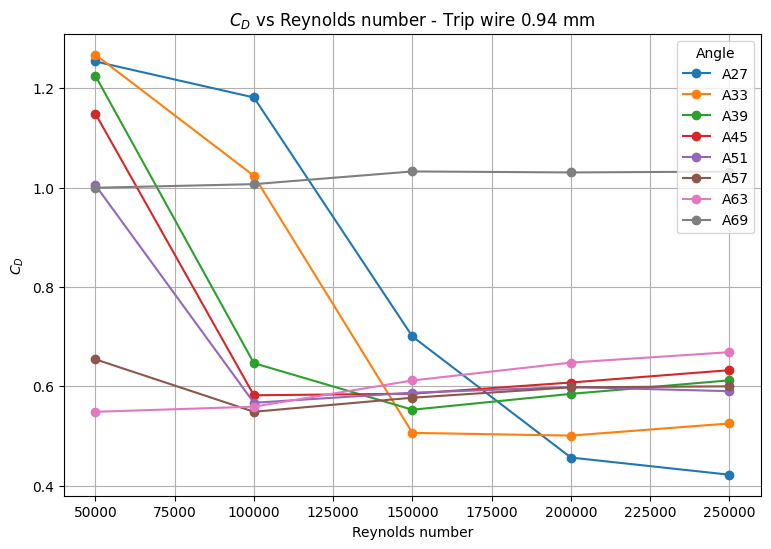

In [66]:

# -----------------------------
# Plot 3: 0.94 mm trip only
# one line per angle
# -----------------------------
trip094_df = results_df[
    (results_df["case"] == "Trip") & (results_df["trip_mm"] == 0.94)
]

plt.figure(figsize=(9, 6))
for angle, group in trip094_df.groupby("angle"):
    group = group.sort_values("Re")
    plt.plot(group["Re"], group["C_D"], "o-", label=f"A{int(angle)}")

plt.xlabel("Reynolds number")
plt.ylabel("$C_D$")
plt.title("$C_D$ vs Reynolds number - Trip wire 0.94 mm")
plt.grid(True)
plt.legend(title="Angle")
plt.show()

### 3D plots

                           file     Re  case  trip_mm  angle      C_D       C_L
        Cyl100_Re050k_Clean.lvm  50000 Clean      NaN    NaN 1.269470 -0.008466
        Cyl100_Re100k_Clean.lvm 100000 Clean      NaN    NaN 1.326420 -0.004858
        Cyl100_Re150k_Clean.lvm 150000 Clean      NaN    NaN 1.390817 -0.010077
        Cyl100_Re200k_Clean.lvm 200000 Clean      NaN    NaN 1.329877 -0.005307
        Cyl100_Re250k_Clean.lvm 250000 Clean      NaN    NaN 1.233705 -0.001398
Cyl100_Re050k_Trip_0.15_A57.lvm  50000  Trip     0.15   57.0 1.228104 -0.008007
Cyl100_Re100k_Trip_0.15_A57.lvm 100000  Trip     0.15   57.0 0.903883  0.153809
Cyl100_Re150k_Trip_0.15_A57.lvm 150000  Trip     0.15   57.0 0.693825  0.232434
Cyl100_Re200k_Trip_0.15_A57.lvm 200000  Trip     0.15   57.0 0.609682 -0.487066
Cyl100_Re250k_Trip_0.15_A57.lvm 250000  Trip     0.15   57.0 0.585929 -0.240304
 Cyl100_Re50k_Trip_0.15_A63.lvm  50000  Trip     0.15   63.0 1.221701 -0.010174
Cyl100_Re100k_Trip_0.15_A63.lvm 100000  

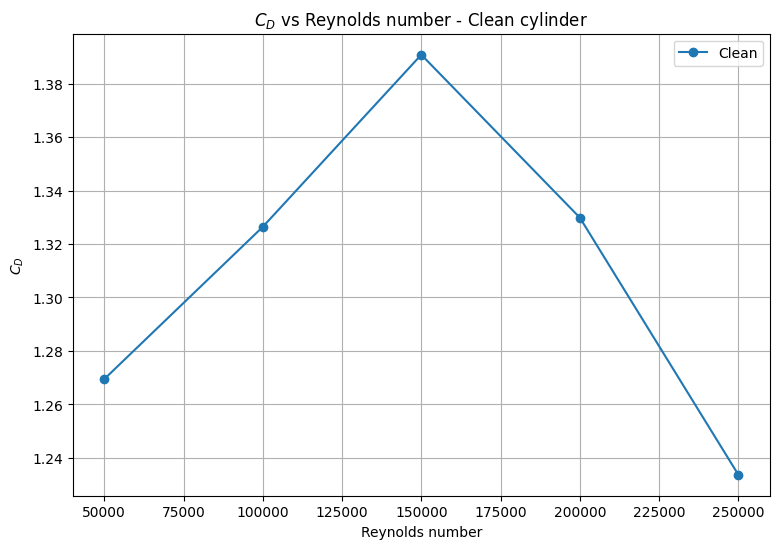

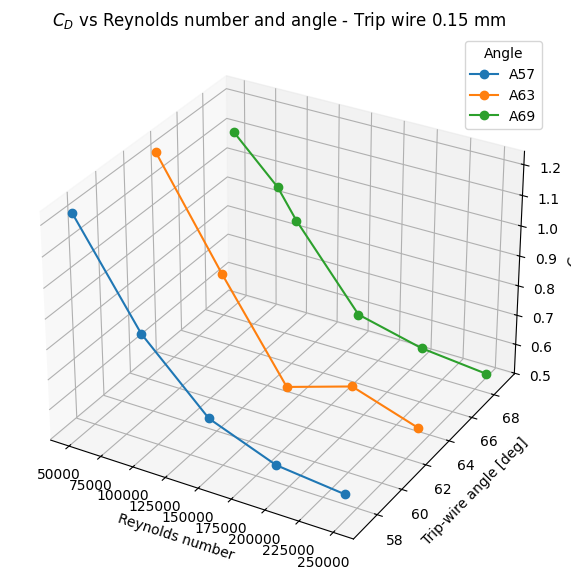

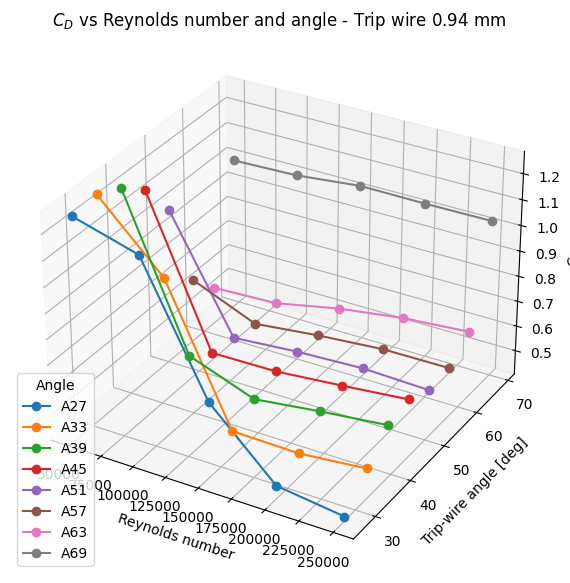

In [67]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

DATA_FOLDER = Path(r"C:\Users\mpciv\Downloads\LVM-20260319T152800Z-3-001\LVM")

LAYER1_COLS_1BASED = (1, 30)
LAYER2_COLS_1BASED = (33, 62)

def read_lvm_file(file_path: Path) -> pd.DataFrame:
    return pd.read_csv(file_path, sep=r"\s+", header=None, engine="python")

def extract_1based_inclusive(df: pd.DataFrame, start: int, end: int) -> np.ndarray:
    return df.iloc[:, start - 1:end].to_numpy()

def parse_filename(file_path: Path):
    parts = file_path.stem.split("_")

    meta = {
        "file": file_path.name,
        "re": int(parts[1].replace("Re", "").replace("k", "")) * 1000,
        "case": None,
        "trip_mm": None,
        "angle": None
    }

    if len(parts) == 3 and parts[2] == "Clean":
        meta["case"] = "Clean"

    elif len(parts) == 5 and parts[2] == "Trip":
        meta["case"] = "Trip"
        meta["trip_mm"] = float(parts[3])
        meta["angle"] = int(parts[4].replace("A", ""))

    else:
        raise ValueError(f"Unexpected filename format: {file_path.name}")

    return meta

results = []

for FILE_PATH in sorted(DATA_FOLDER.glob("*.lvm")):
    meta = parse_filename(FILE_PATH)
    df = read_lvm_file(FILE_PATH)

    layer1 = extract_1based_inclusive(df, *LAYER1_COLS_1BASED)
    layer2 = extract_1based_inclusive(df, *LAYER2_COLS_1BASED)

    p1_mean = layer1.mean(axis=0)
    p2_mean = layer2.mean(axis=0)

    theta_collapsed = np.arange(0.0, 360.0, 6.0)

    q_inf_mean = df.iloc[:, 63].mean()   # pitot channel

    cp1_mean = p1_mean / q_inf_mean
    cp2_mean = p2_mean / q_inf_mean

    cp_collapsed = np.empty(theta_collapsed.size)
    cp_collapsed[0::2] = cp2_mean
    cp_collapsed[1::2] = cp1_mean

    theta_collapsed_closed = np.r_[theta_collapsed, 360.0]
    cp_collapsed_closed = np.r_[cp_collapsed, cp_collapsed[0]]

    theta_rad_closed = np.deg2rad(theta_collapsed_closed)

    # sign chosen to match your current angle convention
    C_D = 0.5 * np.trapz(cp_collapsed_closed * np.cos(theta_rad_closed), theta_rad_closed)
    C_L = 0.5 * np.trapz(cp_collapsed_closed * np.sin(theta_rad_closed), theta_rad_closed)

    results.append({
        "file": meta["file"],
        "Re": meta["re"],
        "case": meta["case"],
        "trip_mm": meta["trip_mm"],
        "angle": meta["angle"],
        "C_D": C_D,
        "C_L": C_L
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values(["case", "trip_mm", "angle", "Re"]).to_string(index=False))

# -----------------------------
# Plot 1: Clean only (2D)
# -----------------------------
clean_df = results_df[results_df["case"] == "Clean"].sort_values("Re")

plt.figure(figsize=(9, 6))
plt.plot(clean_df["Re"], clean_df["C_D"], "o-", label="Clean")
plt.xlabel("Reynolds number")
plt.ylabel("$C_D$")
plt.title("$C_D$ vs Reynolds number - Clean cylinder")
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Plot 2: 0.15 mm trip only (3D)
# x = Re, y = angle, z = C_D
# -----------------------------
trip015_df = results_df[
    (results_df["case"] == "Trip") & (results_df["trip_mm"] == 0.15)
]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

for angle, group in trip015_df.groupby("angle"):
    group = group.sort_values("Re")
    x = group["Re"].to_numpy()
    y = np.full_like(x, angle)
    z = group["C_D"].to_numpy()

    ax.plot(x, y, z, marker="o", label=f"A{int(angle)}")

ax.set_xlabel("Reynolds number")
ax.set_ylabel("Trip-wire angle [deg]")
ax.set_zlabel("$C_D$")
ax.set_title("$C_D$ vs Reynolds number and angle - Trip wire 0.15 mm")
ax.legend(title="Angle")

plt.show()

# -----------------------------
# Plot 3: 0.94 mm trip only (3D)
# x = Re, y = angle, z = C_D
# -----------------------------
trip094_df = results_df[
    (results_df["case"] == "Trip") & (results_df["trip_mm"] == 0.94)
]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

for angle, group in trip094_df.groupby("angle"):
    group = group.sort_values("Re")
    x = group["Re"].to_numpy()
    y = np.full_like(x, angle)
    z = group["C_D"].to_numpy()

    ax.plot(x, y, z, marker="o", label=f"A{int(angle)}")

ax.set_xlabel("Reynolds number")
ax.set_ylabel("Trip-wire angle [deg]")
ax.set_zlabel("$C_D$")
ax.set_title("$C_D$ vs Reynolds number and angle - Trip wire 0.94 mm")
ax.legend(title="Angle")

plt.show()

### Contour plots

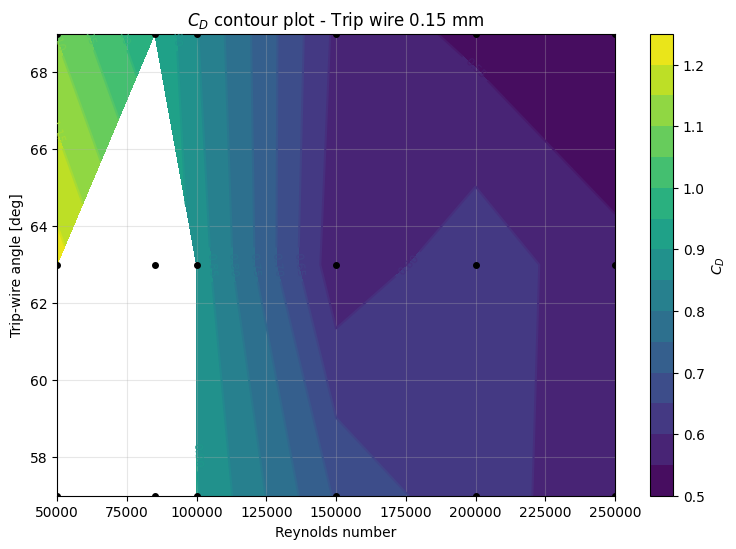

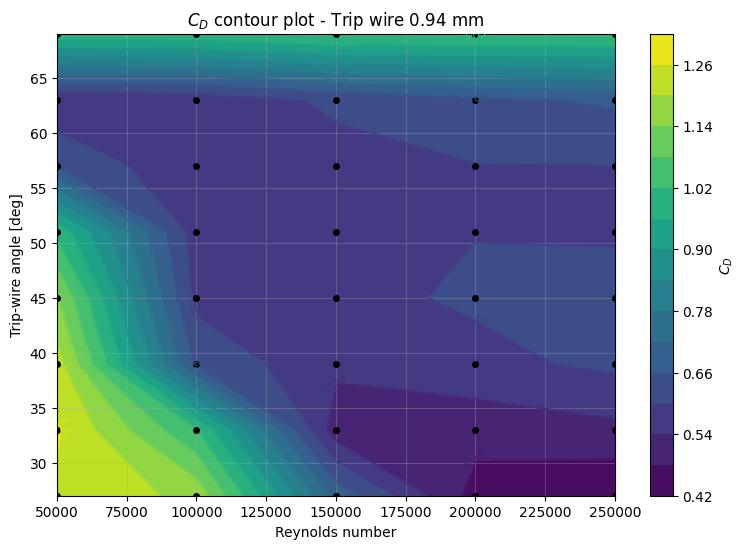

In [68]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_FOLDER = Path(r"C:\Users\mpciv\Downloads\LVM-20260319T152800Z-3-001\LVM")

LAYER1_COLS_1BASED = (1, 30)
LAYER2_COLS_1BASED = (33, 62)

def read_lvm_file(file_path: Path) -> pd.DataFrame:
    return pd.read_csv(file_path, sep=r"\s+", header=None, engine="python")

def extract_1based_inclusive(df: pd.DataFrame, start: int, end: int) -> np.ndarray:
    return df.iloc[:, start - 1:end].to_numpy()

def parse_filename(file_path: Path):
    parts = file_path.stem.split("_")

    meta = {
        "file": file_path.name,
        "re": int(parts[1].replace("Re", "").replace("k", "")) * 1000,
        "case": None,
        "trip_mm": None,
        "angle": None
    }

    if len(parts) == 3 and parts[2] == "Clean":
        meta["case"] = "Clean"

    elif len(parts) == 5 and parts[2] == "Trip":
        meta["case"] = "Trip"
        meta["trip_mm"] = float(parts[3])
        meta["angle"] = int(parts[4].replace("A", ""))

    else:
        raise ValueError(f"Unexpected filename format: {file_path.name}")

    return meta

results = []

for FILE_PATH in sorted(DATA_FOLDER.glob("*.lvm")):
    meta = parse_filename(FILE_PATH)
    df = read_lvm_file(FILE_PATH)

    layer1 = extract_1based_inclusive(df, *LAYER1_COLS_1BASED)
    layer2 = extract_1based_inclusive(df, *LAYER2_COLS_1BASED)

    p1_mean = layer1.mean(axis=0)
    p2_mean = layer2.mean(axis=0)

    theta_collapsed = np.arange(0.0, 360.0, 6.0)

    q_inf_mean = df.iloc[:, 63].mean()

    cp1_mean = p1_mean / q_inf_mean
    cp2_mean = p2_mean / q_inf_mean

    cp_collapsed = np.empty(theta_collapsed.size)
    cp_collapsed[0::2] = cp2_mean
    cp_collapsed[1::2] = cp1_mean

    theta_collapsed_closed = np.r_[theta_collapsed, 360.0]
    cp_collapsed_closed = np.r_[cp_collapsed, cp_collapsed[0]]

    theta_rad_closed = np.deg2rad(theta_collapsed_closed)

    C_D = 0.5 * np.trapz(cp_collapsed_closed * np.cos(theta_rad_closed), theta_rad_closed)
    C_L = 0.5 * np.trapz(cp_collapsed_closed * np.sin(theta_rad_closed), theta_rad_closed)

    results.append({
        "file": meta["file"],
        "Re": meta["re"],
        "case": meta["case"],
        "trip_mm": meta["trip_mm"],
        "angle": meta["angle"],
        "C_D": C_D,
        "C_L": C_L
    })

results_df = pd.DataFrame(results)

# -----------------------------
# Contour plot function
# -----------------------------
def plot_cd_contour(df_trip, trip_mm):
    # Build a grid: rows = angle, columns = Re, values = C_D
    pivot = df_trip.pivot(index="angle", columns="Re", values="C_D")
    pivot = pivot.sort_index().sort_index(axis=1)

    X, Y = np.meshgrid(pivot.columns.to_numpy(), pivot.index.to_numpy())
    Z = pivot.to_numpy()

    plt.figure(figsize=(9, 6))

    # filled contour
    cf = plt.contourf(X, Y, Z, levels=15)
    plt.colorbar(cf, label="$C_D$")

    # contour lines on top
    cs = plt.contour(X, Y, Z, levels=15)
    plt.clabel(cs, inline=True, fontsize=8)

    # mark actual data points
    plt.plot(X.flatten(), Y.flatten(), "ko", markersize=4)

    plt.xlabel("Reynolds number")
    plt.ylabel("Trip-wire angle [deg]")
    plt.title(f"$C_D$ contour plot - Trip wire {trip_mm:.2f} mm")
    plt.grid(True, alpha=0.3)
    plt.show()

# -----------------------------
# 0.15 mm contour
# -----------------------------
trip015_df = results_df[
    (results_df["case"] == "Trip") & (results_df["trip_mm"] == 0.15)
]

plot_cd_contour(trip015_df, 0.15)

# -----------------------------
# 0.94 mm contour
# -----------------------------
trip094_df = results_df[
    (results_df["case"] == "Trip") & (results_df["trip_mm"] == 0.94)
]

plot_cd_contour(trip094_df, 0.94)

## C_L vs Reynolds number

### Code for plotting C_L vs Reynolds number - Including table with sorted values

In [69]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_FOLDER = Path(r"C:\Users\mpciv\Downloads\LVM-20260319T152800Z-3-001\LVM")

LAYER1_COLS_1BASED = (1, 30)
LAYER2_COLS_1BASED = (33, 62)

def read_lvm_file(file_path: Path) -> pd.DataFrame:
    return pd.read_csv(file_path, sep=r"\s+", header=None, engine="python")

def extract_1based_inclusive(df: pd.DataFrame, start: int, end: int) -> np.ndarray:
    return df.iloc[:, start - 1:end].to_numpy()

def parse_filename(file_path: Path):
    parts = file_path.stem.split("_")

    meta = {
        "file": file_path.name,
        "re": int(parts[1].replace("Re", "").replace("k", "")) * 1000,
        "case": None,
        "trip_mm": None,
        "angle": None
    }

    if len(parts) == 3 and parts[2] == "Clean":
        meta["case"] = "Clean"

    elif len(parts) == 5 and parts[2] == "Trip":
        meta["case"] = "Trip"
        meta["trip_mm"] = float(parts[3])
        meta["angle"] = int(parts[4].replace("A", ""))

    else:
        raise ValueError(f"Unexpected filename format: {file_path.name}")

    return meta

results = []

for FILE_PATH in sorted(DATA_FOLDER.glob("*.lvm")):
    meta = parse_filename(FILE_PATH)
    df = read_lvm_file(FILE_PATH)

    layer1 = extract_1based_inclusive(df, *LAYER1_COLS_1BASED)
    layer2 = extract_1based_inclusive(df, *LAYER2_COLS_1BASED)

    p1_mean = layer1.mean(axis=0)
    p2_mean = layer2.mean(axis=0)

    theta_collapsed = np.arange(0.0, 360.0, 6.0)

    q_inf_mean = df.iloc[:, 63].mean()   # pitot channel

    cp1_mean = p1_mean / q_inf_mean
    cp2_mean = p2_mean / q_inf_mean

    cp_collapsed = np.empty(theta_collapsed.size)
    cp_collapsed[0::2] = cp2_mean
    cp_collapsed[1::2] = cp1_mean

    theta_collapsed_closed = np.r_[theta_collapsed, 360.0]
    cp_collapsed_closed = np.r_[cp_collapsed, cp_collapsed[0]]

    theta_rad_closed = np.deg2rad(theta_collapsed_closed)

    # sign chosen to match your current angle convention
    C_D = 0.5 * np.trapz(cp_collapsed_closed * np.cos(theta_rad_closed), theta_rad_closed)
    C_L = 0.5 * np.trapz(cp_collapsed_closed * np.sin(theta_rad_closed), theta_rad_closed)

    results.append({
        "file": meta["file"],
        "Re": meta["re"],
        "case": meta["case"],
        "trip_mm": meta["trip_mm"],
        "angle": meta["angle"],
        "C_D": C_D,
        "C_L": C_L
    })

results_df = pd.DataFrame(results)

def config_label(row):
    if row["case"] == "Clean":
        return "Clean"
    return f'A{int(row["angle"])}'

results_df["config"] = results_df.apply(config_label, axis=1)

print(results_df.sort_values(["case", "trip_mm", "angle", "Re"]).to_string(index=False))



                           file     Re  case  trip_mm  angle      C_D       C_L config
        Cyl100_Re050k_Clean.lvm  50000 Clean      NaN    NaN 1.269470 -0.008466  Clean
        Cyl100_Re100k_Clean.lvm 100000 Clean      NaN    NaN 1.326420 -0.004858  Clean
        Cyl100_Re150k_Clean.lvm 150000 Clean      NaN    NaN 1.390817 -0.010077  Clean
        Cyl100_Re200k_Clean.lvm 200000 Clean      NaN    NaN 1.329877 -0.005307  Clean
        Cyl100_Re250k_Clean.lvm 250000 Clean      NaN    NaN 1.233705 -0.001398  Clean
Cyl100_Re050k_Trip_0.15_A57.lvm  50000  Trip     0.15   57.0 1.228104 -0.008007    A57
Cyl100_Re100k_Trip_0.15_A57.lvm 100000  Trip     0.15   57.0 0.903883  0.153809    A57
Cyl100_Re150k_Trip_0.15_A57.lvm 150000  Trip     0.15   57.0 0.693825  0.232434    A57
Cyl100_Re200k_Trip_0.15_A57.lvm 200000  Trip     0.15   57.0 0.609682 -0.487066    A57
Cyl100_Re250k_Trip_0.15_A57.lvm 250000  Trip     0.15   57.0 0.585929 -0.240304    A57
 Cyl100_Re50k_Trip_0.15_A63.lvm  50000  Tri

### Clean Cylinder, C_L vs Reynolds

0    -0.008466
12   -0.004858
24   -0.010077
36   -0.005307
48   -0.001398
Name: C_L, dtype: float64


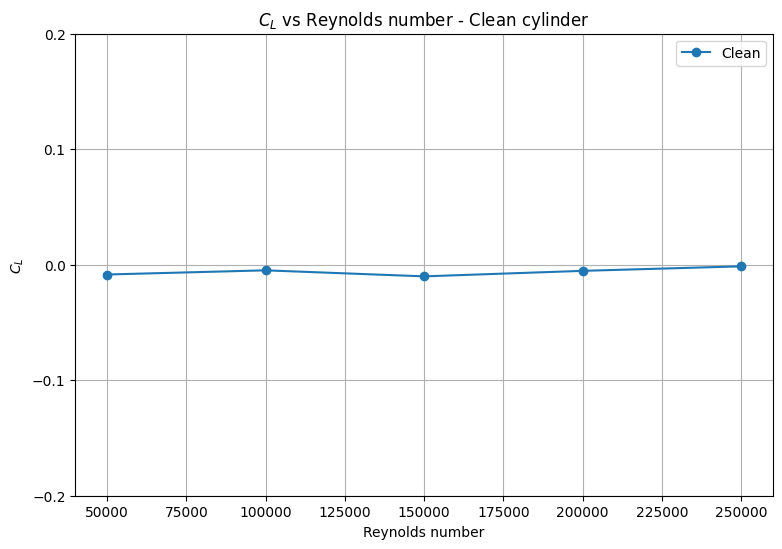

In [70]:

# -----------------------------
# Plot 1: Clean only
# -----------------------------
clean_df = results_df[results_df["case"] == "Clean"].sort_values("Re")

plt.figure(figsize=(9, 6))
plt.plot(clean_df["Re"], clean_df["C_L"], "o-", label="Clean")
plt.xlabel("Reynolds number")
# Source - https://stackoverflow.com/a/43287142
# Posted by Novel
# Retrieved 2026-03-25, License - CC BY-SA 3.0
plt.yticks([-0.2, -0.1, 0, 0.1, 0.2])

print(clean_df["C_L"])
plt.ylabel("$C_L$")
plt.title("$C_L$ vs Reynolds number - Clean cylinder")
plt.grid(True)
plt.legend()
plt.show()

#### Test

### 0.15mm trip wire, C_L vs Reynolds number

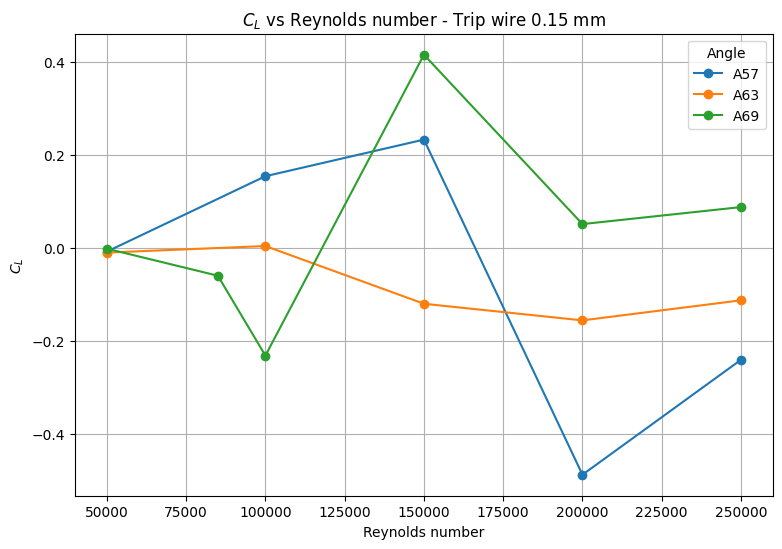

In [71]:
# -----------------------------
# Plot 2: 0.15 mm trip only
# one line per angle
# -----------------------------
trip015_df = results_df[
    (results_df["case"] == "Trip") & (results_df["trip_mm"] == 0.15)
]

plt.figure(figsize=(9, 6))
for angle, group in trip015_df.groupby("angle"):
    group = group.sort_values("Re")
    plt.plot(group["Re"], group["C_L"], "o-", label=f"A{int(angle)}")

plt.xlabel("Reynolds number")
plt.ylabel("$C_L$")
plt.title("$C_L$ vs Reynolds number - Trip wire 0.15 mm")
plt.grid(True)
plt.legend(title="Angle")
plt.show()

### 0.94mm tripwire, C_L vs Reynolds number

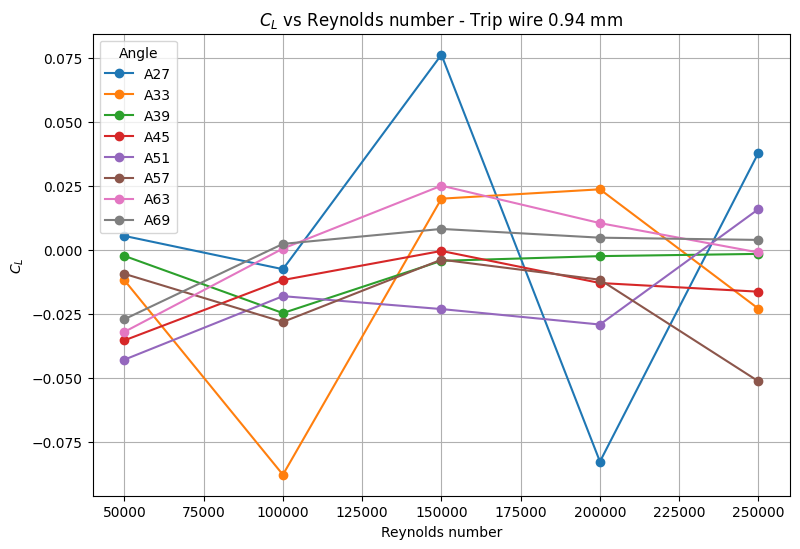

In [72]:

# -----------------------------
# Plot 3: 0.94 mm trip only
# one line per angle
# -----------------------------
trip094_df = results_df[
    (results_df["case"] == "Trip") & (results_df["trip_mm"] == 0.94)
]

plt.figure(figsize=(9, 6))
for angle, group in trip094_df.groupby("angle"):
    group = group.sort_values("Re")
    plt.plot(group["Re"], group["C_L"], "o-", label=f"A{int(angle)}")

plt.xlabel("Reynolds number")
plt.ylabel("$C_L$")
plt.title("$C_L$ vs Reynolds number - Trip wire 0.94 mm")
plt.grid(True)
plt.legend(title="Angle")
plt.show()

### 3D plots

                           file     Re  case  trip_mm  angle      C_D       C_L
        Cyl100_Re050k_Clean.lvm  50000 Clean      NaN    NaN 1.269470 -0.008466
        Cyl100_Re100k_Clean.lvm 100000 Clean      NaN    NaN 1.326420 -0.004858
        Cyl100_Re150k_Clean.lvm 150000 Clean      NaN    NaN 1.390817 -0.010077
        Cyl100_Re200k_Clean.lvm 200000 Clean      NaN    NaN 1.329877 -0.005307
        Cyl100_Re250k_Clean.lvm 250000 Clean      NaN    NaN 1.233705 -0.001398
Cyl100_Re050k_Trip_0.15_A57.lvm  50000  Trip     0.15   57.0 1.228104 -0.008007
Cyl100_Re100k_Trip_0.15_A57.lvm 100000  Trip     0.15   57.0 0.903883  0.153809
Cyl100_Re150k_Trip_0.15_A57.lvm 150000  Trip     0.15   57.0 0.693825  0.232434
Cyl100_Re200k_Trip_0.15_A57.lvm 200000  Trip     0.15   57.0 0.609682 -0.487066
Cyl100_Re250k_Trip_0.15_A57.lvm 250000  Trip     0.15   57.0 0.585929 -0.240304
 Cyl100_Re50k_Trip_0.15_A63.lvm  50000  Trip     0.15   63.0 1.221701 -0.010174
Cyl100_Re100k_Trip_0.15_A63.lvm 100000  

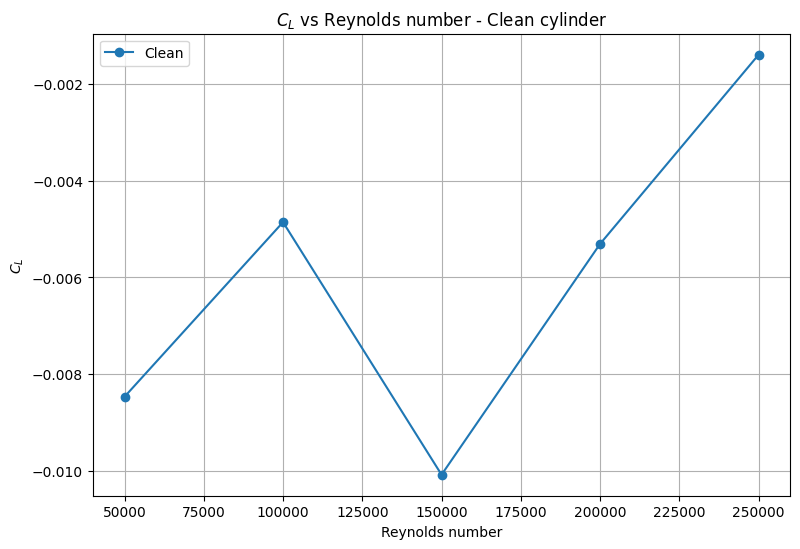

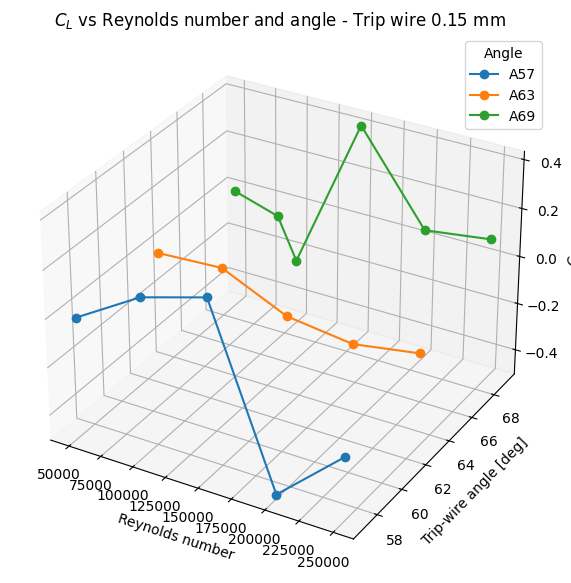

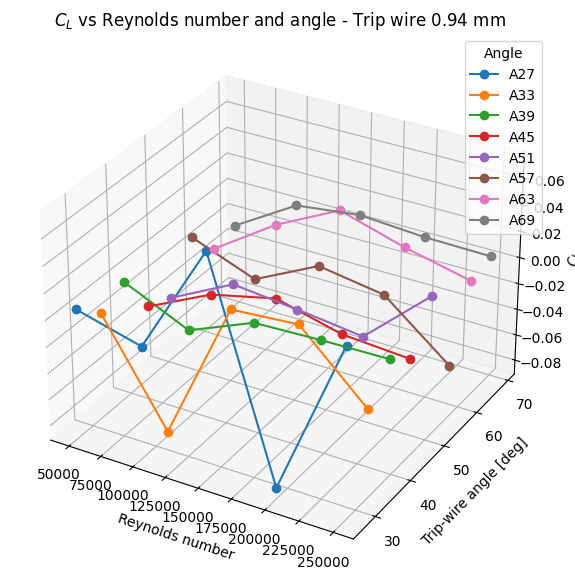

In [73]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

DATA_FOLDER = Path(r"C:\Users\mpciv\Downloads\LVM-20260319T152800Z-3-001\LVM")

LAYER1_COLS_1BASED = (1, 30)
LAYER2_COLS_1BASED = (33, 62)

def read_lvm_file(file_path: Path) -> pd.DataFrame:
    return pd.read_csv(file_path, sep=r"\s+", header=None, engine="python")

def extract_1based_inclusive(df: pd.DataFrame, start: int, end: int) -> np.ndarray:
    return df.iloc[:, start - 1:end].to_numpy()

def parse_filename(file_path: Path):
    parts = file_path.stem.split("_")

    meta = {
        "file": file_path.name,
        "re": int(parts[1].replace("Re", "").replace("k", "")) * 1000,
        "case": None,
        "trip_mm": None,
        "angle": None
    }

    if len(parts) == 3 and parts[2] == "Clean":
        meta["case"] = "Clean"

    elif len(parts) == 5 and parts[2] == "Trip":
        meta["case"] = "Trip"
        meta["trip_mm"] = float(parts[3])
        meta["angle"] = int(parts[4].replace("A", ""))

    else:
        raise ValueError(f"Unexpected filename format: {file_path.name}")

    return meta

results = []

for FILE_PATH in sorted(DATA_FOLDER.glob("*.lvm")):
    meta = parse_filename(FILE_PATH)
    df = read_lvm_file(FILE_PATH)

    layer1 = extract_1based_inclusive(df, *LAYER1_COLS_1BASED)
    layer2 = extract_1based_inclusive(df, *LAYER2_COLS_1BASED)

    p1_mean = layer1.mean(axis=0)
    p2_mean = layer2.mean(axis=0)

    theta_collapsed = np.arange(0.0, 360.0, 6.0)

    q_inf_mean = df.iloc[:, 63].mean()   # pitot channel

    cp1_mean = p1_mean / q_inf_mean
    cp2_mean = p2_mean / q_inf_mean

    cp_collapsed = np.empty(theta_collapsed.size)
    cp_collapsed[0::2] = cp2_mean
    cp_collapsed[1::2] = cp1_mean

    theta_collapsed_closed = np.r_[theta_collapsed, 360.0]
    cp_collapsed_closed = np.r_[cp_collapsed, cp_collapsed[0]]

    theta_rad_closed = np.deg2rad(theta_collapsed_closed)

    # sign chosen to match your current angle convention
    C_D = 0.5 * np.trapz(cp_collapsed_closed * np.cos(theta_rad_closed), theta_rad_closed)
    C_L = 0.5 * np.trapz(cp_collapsed_closed * np.sin(theta_rad_closed), theta_rad_closed)

    results.append({
        "file": meta["file"],
        "Re": meta["re"],
        "case": meta["case"],
        "trip_mm": meta["trip_mm"],
        "angle": meta["angle"],
        "C_D": C_D,
        "C_L": C_L
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values(["case", "trip_mm", "angle", "Re"]).to_string(index=False))

# -----------------------------
# Plot 1: Clean only (2D)
# -----------------------------
clean_df = results_df[results_df["case"] == "Clean"].sort_values("Re")

plt.figure(figsize=(9, 6))
plt.plot(clean_df["Re"], clean_df["C_L"], "o-", label="Clean")
plt.xlabel("Reynolds number")
plt.ylabel("$C_L$")
plt.title("$C_L$ vs Reynolds number - Clean cylinder")
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Plot 2: 0.15 mm trip only (3D)
# x = Re, y = angle, z = C_L
# -----------------------------
trip015_df = results_df[
    (results_df["case"] == "Trip") & (results_df["trip_mm"] == 0.15)
]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

for angle, group in trip015_df.groupby("angle"):
    group = group.sort_values("Re")
    x = group["Re"].to_numpy()
    y = np.full_like(x, angle)
    z = group["C_L"].to_numpy()

    ax.plot(x, y, z, marker="o", label=f"A{int(angle)}")

ax.set_xlabel("Reynolds number")
ax.set_ylabel("Trip-wire angle [deg]")
ax.set_zlabel("$C_L$")
ax.set_title("$C_L$ vs Reynolds number and angle - Trip wire 0.15 mm")
ax.legend(title="Angle")

plt.show()

# -----------------------------
# Plot 3: 0.94 mm trip only (3D)
# x = Re, y = angle, z = C_L
# -----------------------------
trip094_df = results_df[
    (results_df["case"] == "Trip") & (results_df["trip_mm"] == 0.94)
]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

for angle, group in trip094_df.groupby("angle"):
    group = group.sort_values("Re")
    x = group["Re"].to_numpy()
    y = np.full_like(x, angle)
    z = group["C_L"].to_numpy()

    ax.plot(x, y, z, marker="o", label=f"A{int(angle)}")

ax.set_xlabel("Reynolds number")
ax.set_ylabel("Trip-wire angle [deg]")
ax.set_zlabel("$C_L$")
ax.set_title("$C_L$ vs Reynolds number and angle - Trip wire 0.94 mm")
ax.legend(title="Angle")

plt.show()

### Contour plots

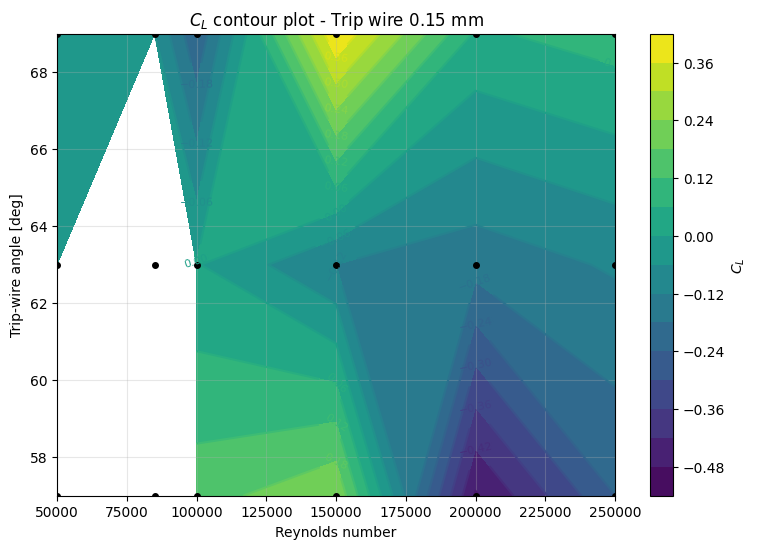

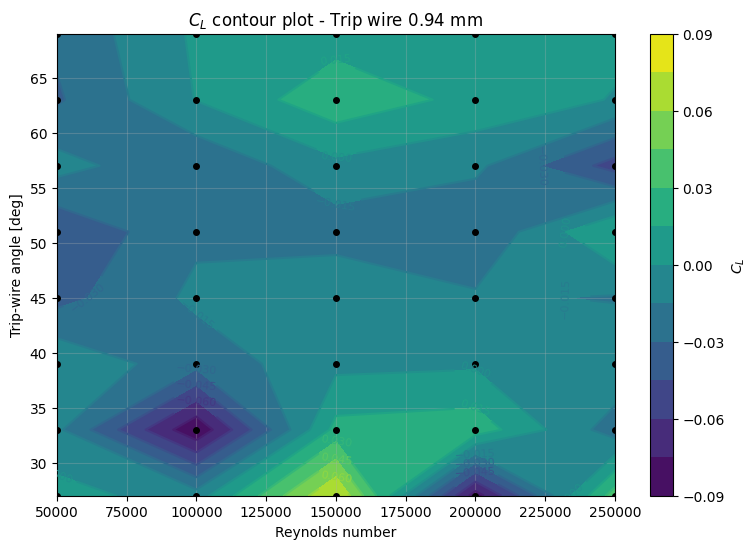

In [74]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_FOLDER = Path(r"C:\Users\mpciv\Downloads\LVM-20260319T152800Z-3-001\LVM")

LAYER1_COLS_1BASED = (1, 30)
LAYER2_COLS_1BASED = (33, 62)

def read_lvm_file(file_path: Path) -> pd.DataFrame:
    return pd.read_csv(file_path, sep=r"\s+", header=None, engine="python")

def extract_1based_inclusive(df: pd.DataFrame, start: int, end: int) -> np.ndarray:
    return df.iloc[:, start - 1:end].to_numpy()

def parse_filename(file_path: Path):
    parts = file_path.stem.split("_")

    meta = {
        "file": file_path.name,
        "re": int(parts[1].replace("Re", "").replace("k", "")) * 1000,
        "case": None,
        "trip_mm": None,
        "angle": None
    }

    if len(parts) == 3 and parts[2] == "Clean":
        meta["case"] = "Clean"

    elif len(parts) == 5 and parts[2] == "Trip":
        meta["case"] = "Trip"
        meta["trip_mm"] = float(parts[3])
        meta["angle"] = int(parts[4].replace("A", ""))

    else:
        raise ValueError(f"Unexpected filename format: {file_path.name}")

    return meta

results = []

for FILE_PATH in sorted(DATA_FOLDER.glob("*.lvm")):
    meta = parse_filename(FILE_PATH)
    df = read_lvm_file(FILE_PATH)

    layer1 = extract_1based_inclusive(df, *LAYER1_COLS_1BASED)
    layer2 = extract_1based_inclusive(df, *LAYER2_COLS_1BASED)

    p1_mean = layer1.mean(axis=0)
    p2_mean = layer2.mean(axis=0)

    theta_collapsed = np.arange(0.0, 360.0, 6.0)

    q_inf_mean = df.iloc[:, 63].mean()

    cp1_mean = p1_mean / q_inf_mean
    cp2_mean = p2_mean / q_inf_mean

    cp_collapsed = np.empty(theta_collapsed.size)
    cp_collapsed[0::2] = cp2_mean
    cp_collapsed[1::2] = cp1_mean

    theta_collapsed_closed = np.r_[theta_collapsed, 360.0]
    cp_collapsed_closed = np.r_[cp_collapsed, cp_collapsed[0]]

    theta_rad_closed = np.deg2rad(theta_collapsed_closed)

    C_D = 0.5 * np.trapz(cp_collapsed_closed * np.cos(theta_rad_closed), theta_rad_closed)
    C_L = 0.5 * np.trapz(cp_collapsed_closed * np.sin(theta_rad_closed), theta_rad_closed)

    results.append({
        "file": meta["file"],
        "Re": meta["re"],
        "case": meta["case"],
        "trip_mm": meta["trip_mm"],
        "angle": meta["angle"],
        "C_D": C_D,
        "C_L": C_L
    })

results_df = pd.DataFrame(results)

# -----------------------------
# Contour plot function
# -----------------------------
def plot_cl_contour(df_trip, trip_mm):
    # Build a grid: rows = angle, columns = Re, values = C_L
    pivot = df_trip.pivot(index="angle", columns="Re", values="C_L")
    pivot = pivot.sort_index().sort_index(axis=1)

    X, Y = np.meshgrid(pivot.columns.to_numpy(), pivot.index.to_numpy())
    Z = pivot.to_numpy()

    plt.figure(figsize=(9, 6))

    # filled contour
    cf = plt.contourf(X, Y, Z, levels=15)
    plt.colorbar(cf, label="$C_L$")

    # contour lines on top
    cs = plt.contour(X, Y, Z, levels=15)
    plt.clabel(cs, inline=True, fontsize=8)

    # mark actual data points
    plt.plot(X.flatten(), Y.flatten(), "ko", markersize=4)

    plt.xlabel("Reynolds number")
    plt.ylabel("Trip-wire angle [deg]")
    plt.title(f"$C_L$ contour plot - Trip wire {trip_mm:.2f} mm")
    plt.grid(True, alpha=0.3)
    plt.show()

# -----------------------------
# 0.15 mm contour
# -----------------------------
trip015_df = results_df[
    (results_df["case"] == "Trip") & (results_df["trip_mm"] == 0.15)
]

plot_cl_contour(trip015_df, 0.15)

# -----------------------------
# 0.94 mm contour
# -----------------------------
trip094_df = results_df[
    (results_df["case"] == "Trip") & (results_df["trip_mm"] == 0.94)
]

plot_cl_contour(trip094_df, 0.94)

# Strouhal number

#### First, we isolate the time from a specific file

In [75]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = Path(r"C:\Users\mpciv\Downloads\LVM-20260319T152800Z-3-001\LVM\Cyl100_Re100k_Clean.lvm")

EXTRA_NAMES = ["pitot", "AoA", "F", "alpha", "P_m", "V_tunnel", "rho", "time"]

def read_lvm_file(file_path: Path) -> pd.DataFrame:
    return pd.read_csv(file_path, sep=r"\s+", header=None, engine="python")

def parse_filename(file_path: Path):
    parts = file_path.stem.split("_")
    return {
        "re": parts[1],
        "case": parts[2]
    }

# Read just this one file
df = read_lvm_file(FILE_PATH)
meta = parse_filename(FILE_PATH)

# Extract the extra channels
extra_data = df.iloc[:, 63:71].copy()
extra_data.columns = EXTRA_NAMES

# Plot each variable for this one run
# for col in EXTRA_NAMES:
#     plt.figure(figsize=(10, 5))
#     plt.plot(extra_data.index, extra_data[col])

#     plt.xlabel("Sample number")
#     plt.ylabel(col)
#     plt.title(f"{col} for {meta['re']} {meta['case']}")
#     plt.grid(True)

# plt.show()

# Make one summary table for this file
summary_rows = []

for col in EXTRA_NAMES:
    series = extra_data[col]
    summary_rows.append({
        "variable": col,
        "mean": series.mean(),
        "std": series.std(),
        "min": series.min(),
        "max": series.max()
    })

summary_df = pd.DataFrame(summary_rows)

# print("\nSummary table for selected file:")
# print(summary_df)



for col in EXTRA_NAMES:
    if col != "time":
        continue
    print(extra_data[col])


0       -0.000024
1        0.003869
2        0.007812
3        0.011852
4        0.015843
          ...    
4995    20.029718
4996    20.033612
4997    20.037526
4998    20.041512
4999    20.045610
Name: time, Length: 5000, dtype: float64


### C_L not as a mean value

       time       C_L       C_D
0 -0.000024 -0.099558  1.122660
1  0.003869 -0.105448  1.204686
2  0.007812 -0.078067  1.157200
3  0.011852  0.003994  1.102183
4  0.015843  0.082101  1.136279


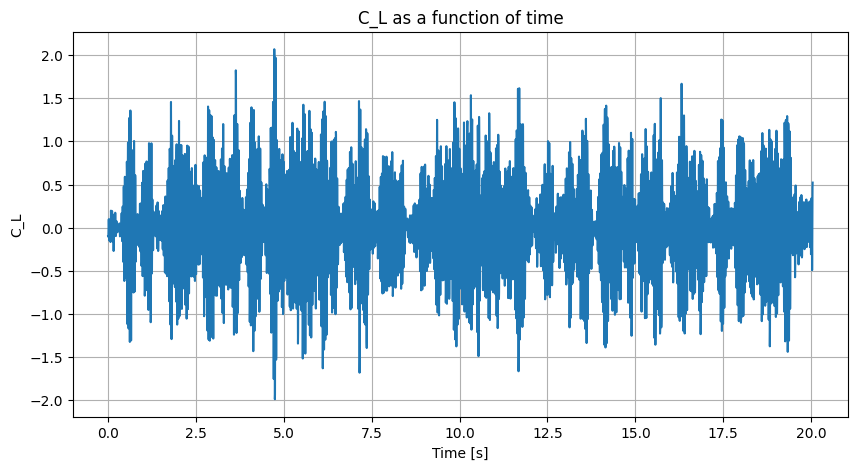

In [76]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = Path(r"C:\Users\mpciv\Downloads\LVM-20260319T152800Z-3-001\LVM\Cyl100_Re100k_Clean.lvm")

LAYER1_COLS_1BASED = (1, 30)
LAYER2_COLS_1BASED = (33, 62)

EXTRA_NAMES = ["pitot", "AoA", "F", "alpha", "P_m", "V_tunnel", "rho", "time"]

def read_lvm_file(file_path: Path) -> pd.DataFrame:
    return pd.read_csv(file_path, sep=r"\s+", header=None, engine="python")

def extract_1based_inclusive(df: pd.DataFrame, start: int, end: int) -> np.ndarray:
    return df.iloc[:, start - 1:end].to_numpy()

df = read_lvm_file(FILE_PATH)

# Pressure tap data: shape = (n_samples, 30)
layer1 = extract_1based_inclusive(df, *LAYER1_COLS_1BASED)
layer2 = extract_1based_inclusive(df, *LAYER2_COLS_1BASED)

# Extra channels
extra_data = df.iloc[:, 63:71].copy()
extra_data.columns = EXTRA_NAMES

# Time and pitot as time series
time = extra_data["time"].to_numpy()
q_inf = extra_data["pitot"].to_numpy()

# Avoid division by zero
eps = 1e-12
q_inf = np.where(np.abs(q_inf) < eps, np.nan, q_inf)

# Cp(t, theta) for every sample
cp1 = layer1 / q_inf[:, None]
cp2 = layer2 / q_inf[:, None]

# Angular positions
theta_collapsed = np.arange(0.0, 360.0, 6.0)   # 60 positions
theta_collapsed_closed = np.r_[theta_collapsed, 360.0]
theta_rad_closed = np.deg2rad(theta_collapsed_closed)

n_samples = df.shape[0]
cp_collapsed = np.empty((n_samples, theta_collapsed.size))

# Interleave the two layers exactly as before
cp_collapsed[:, 0::2] = cp2
cp_collapsed[:, 1::2] = cp1

# Close the curve in theta for integration
cp_collapsed_closed = np.hstack([cp_collapsed, cp_collapsed[:, [0]]])

# Compute C_L(t) and C_D(t)
C_L_t = 0.5 * np.trapz(cp_collapsed_closed * np.sin(theta_rad_closed), theta_rad_closed, axis=1)
C_D_t = 0.5 * np.trapz(cp_collapsed_closed * np.cos(theta_rad_closed), theta_rad_closed, axis=1)

# Put in dataframe
results_t = pd.DataFrame({
    "time": time,
    "C_L": C_L_t,
    "C_D": C_D_t
})

print(results_t.head())

# Plot C_L(t)
plt.figure(figsize=(10, 5))
plt.plot(results_t["time"], results_t["C_L"])
plt.xlabel("Time [s]")
plt.ylabel("C_L")
plt.title("C_L as a function of time")
plt.grid(True)
plt.show()

## Strouhal number calculation finder

File: Cyl100_Re150k_Trip_0.94_A27.lvm
Number of samples used for FFT: 4500
Mean velocity U = 22.7401 m/s
Dominant shedding frequency f = 57.1362 Hz
Strouhal number St = 0.2513
Drag coefficient, C_D mean = 0.7003, std = 0.0397


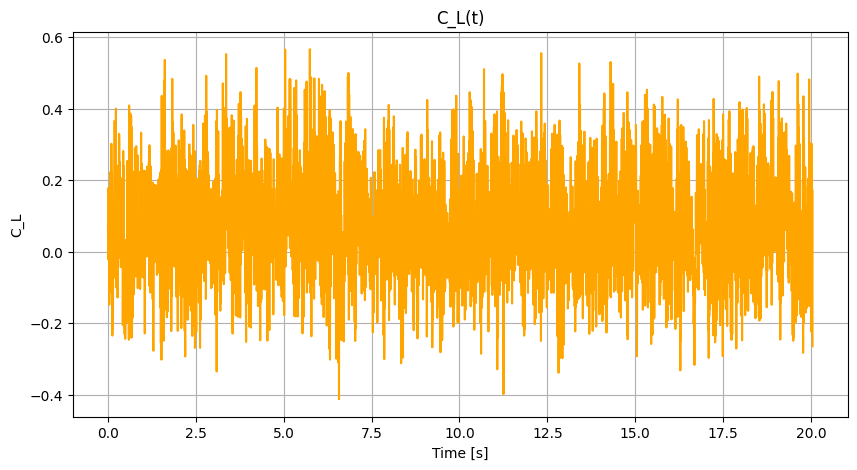

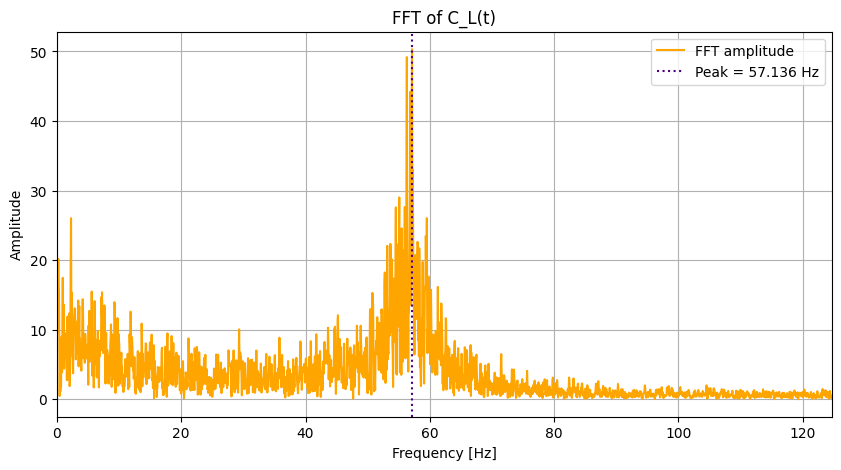

In [77]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = Path(r"C:\Users\mpciv\Downloads\LVM-20260319T152800Z-3-001\LVM\Cyl100_Re150k_Trip_0.94_A27.lvm")

LAYER1_COLS_1BASED = (1, 30)
LAYER2_COLS_1BASED = (33, 62)

EXTRA_NAMES = ["pitot", "AoA", "F", "alpha", "P_m", "V_tunnel", "rho", "time"]

D = 0.100   # cylinder diameter [m] - change if needed

def read_lvm_file(file_path: Path) -> pd.DataFrame:
    return pd.read_csv(file_path, sep=r"\s+", header=None, engine="python")

def extract_1based_inclusive(df: pd.DataFrame, start: int, end: int) -> np.ndarray:
    return df.iloc[:, start - 1:end].to_numpy()

df = read_lvm_file(FILE_PATH)

# Pressure tap data
layer1 = extract_1based_inclusive(df, *LAYER1_COLS_1BASED)   # shape (n_samples, 30)
layer2 = extract_1based_inclusive(df, *LAYER2_COLS_1BASED)   # shape (n_samples, 30)

# Extra channels
extra_data = df.iloc[:, 63:71].copy()
extra_data.columns = EXTRA_NAMES

time = extra_data["time"].to_numpy()
q_inf = extra_data["pitot"].to_numpy()
U_tunnel = extra_data["V_tunnel"].to_numpy()

# Avoid division by zero
eps = 1e-12
q_inf = np.where(np.abs(q_inf) < eps, np.nan, q_inf)

# Cp for every sample
cp1 = layer1 / q_inf[:, None]
cp2 = layer2 / q_inf[:, None]

# Angular positions
theta_collapsed = np.arange(0.0, 360.0, 6.0)   # 60 positions
theta_collapsed_closed = np.r_[theta_collapsed, 360.0]
theta_rad_closed = np.deg2rad(theta_collapsed_closed)

# Interleave tap rows into one circumferential Cp distribution per sample
n_samples = df.shape[0]
cp_collapsed = np.empty((n_samples, theta_collapsed.size))
cp_collapsed[:, 0::2] = cp2
cp_collapsed[:, 1::2] = cp1

# Close the loop for integration
cp_collapsed_closed = np.hstack([cp_collapsed, cp_collapsed[:, [0]]])

# Compute C_L(t) and C_D(t)
C_L_t = 0.5 * np.trapz(
    cp_collapsed_closed * np.sin(theta_rad_closed),
    theta_rad_closed,
    axis=1
)
C_D_t = 0.5 * np.trapz(
    cp_collapsed_closed * np.cos(theta_rad_closed),
    theta_rad_closed,
    axis=1
)

# Build results table
results_t = pd.DataFrame({
    "time": time,
    "C_L": C_L_t,
    "C_D": C_D_t,
    "V_tunnel": U_tunnel
})

# Remove bad rows
results_t = results_t.replace([np.inf, -np.inf], np.nan).dropna(subset=["time", "C_L", "V_tunnel"])

# Optional: remove initial transient (first 10%)
start_idx = int(0.10 * len(results_t))
results_fft = results_t.iloc[start_idx:].copy()

# Extract arrays for FFT
time_fft = results_fft["time"].to_numpy()
cl_fft = results_fft["C_L"].to_numpy()

# Remove mean from C_L(t)
cl_fluct = cl_fft - np.mean(cl_fft)

# Sampling interval from time series
dt = np.mean(np.diff(time_fft))

# FFT with Hann window
n = len(cl_fluct)
window = np.hanning(n)
cl_windowed = cl_fluct * window

freqs = np.fft.rfftfreq(n, d=dt)
fft_vals = np.fft.rfft(cl_windowed)
amplitude = np.abs(fft_vals)

# Remove zero-frequency component
freqs_nozero = freqs[1:]
amplitude_nozero = amplitude[1:]

# Optional: restrict search range to avoid drift/high-frequency noise
# Adjust bounds if needed
f_min = 1.0
f_max = 500.0

band_mask = (freqs_nozero >= f_min) & (freqs_nozero <= f_max)

freqs_band = freqs_nozero[band_mask]
amplitude_band = amplitude_nozero[band_mask]

dominant_index = np.argmax(amplitude_band)
f_shedding = freqs_band[dominant_index]

# Mean tunnel velocity
U_mean = results_fft["V_tunnel"].mean()

# Strouhal number
St = f_shedding * D / U_mean

print(f"File: {FILE_PATH.name}")
print(f"Number of samples used for FFT: {n}")
print(f"Mean velocity U = {U_mean:.4f} m/s")
print(f"Dominant shedding frequency f = {f_shedding:.4f} Hz")
print(f"Strouhal number St = {St:.4f}")
print(f"Drag coefficient, C_D mean = {results_t['C_D'].mean():.4f}, std = {results_t['C_D'].std():.4f}")

# Plot C_L(t)
plt.figure(figsize=(10, 5))
plt.plot(results_t["time"], results_t["C_L"], color = "orange")
plt.xlabel("Time [s]")
plt.ylabel("C_L")
plt.title("C_L(t)")
plt.grid(True)

# Plot FFT spectrum
plt.figure(figsize=(10, 5))
plt.plot(freqs_nozero, amplitude_nozero, label="FFT amplitude", color = "orange")
plt.axvline(f_shedding, linestyle="dotted", label=f"Peak = {f_shedding:.3f} Hz", color = "indigo")
plt.xlim(0, min(200, freqs_nozero.max()))  # adjust if needed
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.title("FFT of C_L(t)")
plt.grid(True)
plt.legend()

plt.show()